# Synthetic Fraud Dataset Validation (DAT610)

We take a real vehicle insurance claims dataset, generate a synthetic copy of it with **CTGAN**
(a GAN designed for tabular data), and then put that synthetic copy through a **five-level
validation framework**:

| Level | Name | What it checks |
|---|---|---|
| 1 | Summary Statistics | Do the numbers have the same centre and spread? |
| 2 | Visual Distributions | Do the distributions and relationships *look* the same? |
| 3 | Statistical Tests | Are the differences big enough for a formal test to detect? |
| 4 | ML Utility (TSTR) | Can a fraud model trained only on synthetic claims still catch real fraud? |
| 5 | Privacy (DNNR) | Did the generator memorise any real claimants? |


---
## Step 1. Environment setup

Import the libraries and fix a single random seed everywhere so that the whole notebook is
reproducible

In [1]:
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import ks_2samp, chi2_contingency, wasserstein_distance

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
)

# Synthetic data generator
import torch
from ctgan import CTGAN

warnings.filterwarnings("ignore")
%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# The seed alone is NOT enough. PyTorch splits its CPU work across threads, and the order in
# which those threads combine their partial sums depends on how many there are. Different
# thread counts give slightly different floating point results, and over 300 training epochs
# that difference compounds into visibly different synthetic data. Left unpinned, the thread
# count follows whatever the machine happens to make available, so the same seed on the same
# machine can still produce a different dataset. Pinning it is what makes the run repeatable.
TORCH_THREADS = 4
torch.set_num_threads(TORCH_THREADS)

# Output folders
FIG_DIR = "figures"
OUT_DIR = "outputs"
DATA_DIR = "data"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Consistent plot styling across the whole notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 10
C_REAL, C_SYNTH = "#2b6cb0", "#dd6b20"

# RESULTS collects every numbers and statictis
RESULTS = {}

## Step 2. Load and explore the real data

The real dataset is the **Vehicle Insurance Fraud Detection** dataset from Kaggle
(<https://www.kaggle.com/datasets/khusheekapoor/vehicle-insurance-fraud-detection>), supplied as
`carclaims.csv`. Each row is one motor insurance claim, described by details of the policy, the
vehicle, the accident and the claimant. One column flags whether the claim was later found to be
fraudulent.

In [2]:
# Load the real dataset
real_raw = pd.read_csv(os.path.join(DATA_DIR, "carclaims.csv"))

print("Shape (rows, columns):", real_raw.shape)
print()
print("First 5 rows:")
real_raw.head()

Shape (rows, columns): (15420, 33)

First 5 rows:


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [3]:
# Column types and missing values
info = pd.DataFrame({
    "dtype": real_raw.dtypes.astype(str),
    "n_unique": real_raw.nunique(),
    "n_missing": real_raw.isna().sum(),
})
print("Total missing values in the entire dataset:", int(real_raw.isna().sum().sum()))
print()
info

Total missing values in the entire dataset: 0



,dtype,n_unique,n_missing
Month,object,12,0
WeekOfMonth,int64,5,0
DayOfWeek,object,7,0
Make,object,19,0
AccidentArea,object,2,0
DayOfWeekClaimed,object,8,0
MonthClaimed,object,13,0
WeekOfMonthClaimed,int64,5,0
Sex,object,2,0
MaritalStatus,object,4,0


There are no missing values anywhere, which removes a whole class of complications. And also, there are no duplicate rows, which is useful to know

In [4]:
# Confirm the suspicion about PolicyNumber before we act on it
is_sequential_id = bool((real_raw["PolicyNumber"].values == np.arange(1, len(real_raw) + 1)).all())
print("PolicyNumber is exactly the sequence 1..N:", is_sequential_id)
print("PolicyNumber unique values:", real_raw["PolicyNumber"].nunique(), "of", len(real_raw), "rows")

# Also check for duplicated claims, which matters later for the privacy level
print("Exact duplicate rows in the real data:", int(real_raw.duplicated().sum()))

PolicyNumber is exactly the sequence 1..N: True
PolicyNumber unique values: 15420 of 15420 rows
Exact duplicate rows in the real data: 0


`PolicyNumber` is literally the row number 1 to 15,420. It carries no
information about fraud and cannot be meaningfully synthesised, so we **drop it**.

In [5]:
# Prepare the modelling dataframe
real = real_raw.drop(columns=["PolicyNumber"]).copy()
real["FraudFound_P"] = (real["FraudFound"] == "Yes").astype(int)
real = real.drop(columns=["FraudFound"])

TARGET = "FraudFound_P"

print("Modelling dataframe shape:", real.shape)
print()

# Class balance of the target
counts = real[TARGET].value_counts().sort_index()
props = real[TARGET].value_counts(normalize=True).sort_index()
balance = pd.DataFrame({
    "label": ["0 = legitimate", "1 = fraud"],
    "count": counts.values,
    "percent": (props.values * 100).round(2),
})
print("Class balance of the target:")
print(balance.to_string(index=False))

REAL_FRAUD_RATE = float(props.loc[1])
print(f"\nFraud rate in the real data: {REAL_FRAUD_RATE:.4%}")
print(f"Imbalance ratio: about 1 fraudulent claim for every {counts.loc[0] / counts.loc[1]:.1f} legitimate claims")

RESULTS["real_shape"] = list(real.shape)
RESULTS["real_fraud_rate"] = REAL_FRAUD_RATE
RESULTS["real_fraud_count"] = int(counts.loc[1])
RESULTS["real_legit_count"] = int(counts.loc[0])

Modelling dataframe shape: (15420, 32)

Class balance of the target:
         label  count  percent
0 = legitimate  14497    94.01
     1 = fraud    923     5.99

Fraud rate in the real data: 5.9857%
Imbalance ratio: about 1 fraudulent claim for every 15.7 legitimate claims


The dataset is **heavily imbalanced**. Only about 6 claims in every 100 are
fraudulent. This single fact shapes the rest of the notebook. A generator that slightly
under-produces fraud cases will strip out most of the signal a fraud model needs, and an accuracy
score of 94% can be achieved by a model that simply never predicts fraud at all.

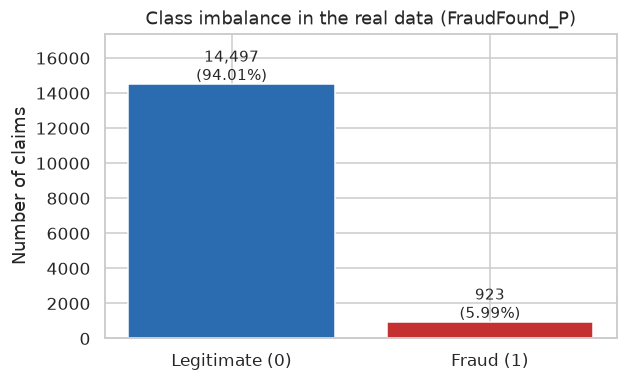

In [6]:
# Visualise the class imbalance
fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar(["Legitimate (0)", "Fraud (1)"], counts.values, color=[C_REAL, "#c53030"])
for b, v, p in zip(bars, counts.values, props.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 250, f"{v:,}\n({p:.2%})", ha="center", fontsize=10)
ax.set_ylabel("Number of claims")
ax.set_title("Class imbalance in the real data (FraudFound_P)")
ax.set_ylim(0, counts.max() * 1.2)
plt.savefig(f"{FIG_DIR}/00_class_balance.png")
plt.show()

In [7]:
# Split the columns into numeric and categorical.
NUMERIC_COLS = [c for c in real.columns if real[c].dtype != "object" and c != TARGET]
CATEGORICAL_COLS = [c for c in real.columns if real[c].dtype == "object"] + [TARGET]

print(f"NUMERIC COLUMNS ({len(NUMERIC_COLS)}):")
for c in NUMERIC_COLS:
    print(f"   {c:<22} range {real[c].min():>6} to {real[c].max():<6} ({real[c].nunique()} distinct values)")

print(f"\nCATEGORICAL COLUMNS ({len(CATEGORICAL_COLS)}):")
for c in CATEGORICAL_COLS:
    print(f"   {c:<22} {real[c].nunique():>3} categories   e.g. {list(real[c].unique()[:3])}")

print(f"\nTotal columns modelled: {len(NUMERIC_COLS) + len(CATEGORICAL_COLS)} (target included)")
print("Dropped from modelling: PolicyNumber (row identifier)")

RESULTS["numeric_cols"] = NUMERIC_COLS
RESULTS["categorical_cols"] = CATEGORICAL_COLS

NUMERIC COLUMNS (7):
   WeekOfMonth            range      1 to 5      (5 distinct values)
   WeekOfMonthClaimed     range      1 to 5      (5 distinct values)
   Age                    range      0 to 80     (66 distinct values)
   RepNumber              range      1 to 16     (16 distinct values)
   Deductible             range    300 to 700    (4 distinct values)
   DriverRating           range      1 to 4      (4 distinct values)
   Year                   range   1994 to 1996   (3 distinct values)

CATEGORICAL COLUMNS (25):
   Month                   12 categories   e.g. ['Dec', 'Jan', 'Oct']
   DayOfWeek                7 categories   e.g. ['Wednesday', 'Friday', 'Saturday']
   Make                    19 categories   e.g. ['Honda', 'Toyota', 'Ford']
   AccidentArea             2 categories   e.g. ['Urban', 'Rural']
   DayOfWeekClaimed         8 categories   e.g. ['Tuesday', 'Monday', 'Thursday']
   MonthClaimed            13 categories   e.g. ['Jan', 'Nov', 'Jul']
   Sex            

Going through the columns, additional information were gotten. `RepNumber` is an identifier for the
insurance representative handling the claim (codes 1 to 16) and `Year` takes only three values
(1994, 1995, 1996). Their averages are not meaningful quantities in the real world. We still
carry them through the numeric checks because comparing their *distributions* between real and
synthetic data is a legitimate and useful test, but we will not over-interpret their means.

`Age` is the only genuinely continuous column, so it carries most of the weight in the numeric
parts of Levels 1, 2 and 3.

In [8]:
# A data quality note we need to be aware of before comparing distributions
zero_age = int((real["Age"] == 0).sum())
print(f"Claims recorded with Age = 0: {zero_age} ({zero_age / len(real):.2%} of rows)")
print("Age summary excluding the zeros:")
print(real.loc[real["Age"] > 0, "Age"].describe().round(2).to_string())

RESULTS["real_age_zero_count"] = zero_age

Claims recorded with Age = 0: 320 (2.08% of rows)
Age summary excluding the zeros:
count    15100.00
mean        40.70
std         12.31
min         16.00
25%         31.00
50%         39.00
75%         49.00
max         80.00


---
## Step 3. Train CTGAN and generate the synthetic data

CTGAN (Conditional Tabular GAN) is a generative adversarial
network built specifically for table data. Two neural networks are trained against each other: a
*generator* invents fake claims, and a *discriminator* tries to tell the fakes from the real ones.
As training proceeds the generator gets better at fooling the discriminator, and the fake claims
start to look statistically like the real ones. CTGAN adds two features that matter for insurance
data: it handles categorical columns natively, and its conditional sampling is designed to give
rare categories a fair chance of being learned rather than being drowned out by common ones.

We train for **300 epochs**. Fewer epochs risk an undertrained generator; many more risk the generator starting to
memorise individual claims, which would hurt down the line

In [9]:
# CTGAN needs to be told which columns are discrete, otherwise it treats everything as continuous.
# We pass the full categorical list, including the encoded target, so fraud/legitimate is modelled
# as a category rather than as a number that could come out as 0.37.
DISCRETE_COLUMNS = CATEGORICAL_COLS
EPOCHS = 300
BATCH_SIZE = 500

print(f"Training CTGAN on {real.shape[0]:,} real claims and {real.shape[1]} columns")
print(f"Discrete columns passed to CTGAN: {len(DISCRETE_COLUMNS)}")
print(f"Continuous columns inferred by CTGAN: {len(NUMERIC_COLS)}")
print(f"Epochs: {EPOCHS} | batch size: {BATCH_SIZE}")
print()

t0 = time.time()
ctgan = CTGAN(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True,
    enable_gpu=False,    # this machine has no GPU
)
# Pin CTGAN's own generators rather than relying on the global seeds set at the top. This
# makes fit and sample reproducible regardless of how much randomness the cells above
# consumed, so inserting a cell earlier in the notebook cannot shift the synthetic data.
ctgan.set_random_state(SEED)
ctgan.fit(real, discrete_columns=DISCRETE_COLUMNS)
train_seconds = time.time() - t0

print(f"\nCTGAN training finished in {train_seconds/60:.1f} minutes")
RESULTS["ctgan_epochs"] = EPOCHS
RESULTS["ctgan_batch_size"] = BATCH_SIZE
RESULTS["ctgan_train_minutes"] = round(train_seconds / 60, 2)

Training CTGAN on 15,420 real claims and 32 columns
Discrete columns passed to CTGAN: 25
Continuous columns inferred by CTGAN: 7
Epochs: 300 | batch size: 500



Gen. (-02.06) | Discrim. (+01.20): 100%|██████████| 300/300 [33:59<00:00,  6.80s/it]


CTGAN training finished in 34.3 minutes


In [10]:
# Sample a synthetic dataset of exactly the same size as the real one
synth_raw = ctgan.sample(len(real))
print("Raw synthetic shape:", synth_raw.shape)
print()
print("Numeric columns straight out of CTGAN (note the decimals):")
print(synth_raw[NUMERIC_COLS].head(3).to_string())

Raw synthetic shape: (15420, 32)

Numeric columns straight out of CTGAN (note the decimals):
   WeekOfMonth  WeekOfMonthClaimed  Age  RepNumber  Deductible  DriverRating  Year
0            4                   1   32          3         400             2  1994
1            3                   4   27         15         400             2  1996
2            1                   4   41          6         501             4  1996


CTGAN models continuous columns on a smoothed
scale, so it returns values like `Age = 38.42` and `Year = 1994.83`. In the real table these
columns are always whole numbers, and a year of 1994.83 does not exist. We therefore apply the
same light post-processing that the SDV library applies by default:

1. **round** each numeric column back to a whole number, and
2. **clip** it into the minimum and maximum actually observed in the real data.

This is standard practice and it does not invent information: it only enforces constraints that
the real data already obeys. We record how much clipping was needed, because a lot of clipping
would itself be a warning sign.

In [11]:
# Post-process the numeric columns: round to integers and clip to the real observed range
synth = synth_raw.copy()
clip_report = []
for c in NUMERIC_COLS:
    lo, hi = real[c].min(), real[c].max()
    before = synth[c]
    n_below = int((before < lo).sum())
    n_above = int((before > hi).sum())
    synth[c] = np.clip(np.round(before), lo, hi).astype(int)
    clip_report.append({
        "column": c, "real_min": lo, "real_max": hi,
        "n_below_min": n_below, "n_above_max": n_above,
        "pct_clipped": round(100 * (n_below + n_above) / len(synth), 3),
    })

# Keep the column order identical to the real dataframe
synth = synth[real.columns]

clip_df = pd.DataFrame(clip_report)
print("Rounding and clipping applied to numeric columns:")
print(clip_df.to_string(index=False))
print(f"\nTotal values clipped across all numeric columns: {clip_df[['n_below_min','n_above_max']].values.sum()}")

RESULTS["clipping"] = clip_df.to_dict("records")

Rounding and clipping applied to numeric columns:
            column  real_min  real_max  n_below_min  n_above_max  pct_clipped
       WeekOfMonth         1         5            0            0        0.000
WeekOfMonthClaimed         1         5            0            0        0.000
               Age         0        80          184            3        1.213
         RepNumber         1        16            3            6        0.058
        Deductible       300       700            0          109        0.707
      DriverRating         1         4            0            0        0.000
              Year      1994      1996            0            0        0.000

Total values clipped across all numeric columns: 305


In [12]:
# Save both datasets.
real_out = os.path.join(OUT_DIR, "real_carclaims_processed.csv")
synth_out = os.path.join(OUT_DIR, "synthetic_carclaims_ctgan.csv")
real.to_csv(real_out, index=False)
synth.to_csv(synth_out, index=False)

print("Saved:")
print(f"  real      -> {real_out}  {real.shape}")
print(f"  synthetic -> {synth_out}  {synth.shape}")
print()

# TChecking if the fraud rate survived
synth_counts = synth[TARGET].value_counts().sort_index()
SYNTH_FRAUD_RATE = float(synth[TARGET].mean())
print(f"Real fraud rate      : {REAL_FRAUD_RATE:.4%}  ({RESULTS['real_fraud_count']:,} fraud cases)")
print(f"Synthetic fraud rate : {SYNTH_FRAUD_RATE:.4%}  ({int(synth_counts.get(1, 0)):,} fraud cases)")
print(f"Absolute difference  : {abs(SYNTH_FRAUD_RATE - REAL_FRAUD_RATE)*100:.2f} percentage points")
print(f"Relative difference  : {(SYNTH_FRAUD_RATE - REAL_FRAUD_RATE)/REAL_FRAUD_RATE*100:+.1f}%")

RESULTS["synth_shape"] = list(synth.shape)
RESULTS["synth_fraud_rate"] = SYNTH_FRAUD_RATE
RESULTS["synth_fraud_count"] = int(synth_counts.get(1, 0))
RESULTS["fraud_rate_abs_diff_pp"] = abs(SYNTH_FRAUD_RATE - REAL_FRAUD_RATE) * 100

Saved:
  real      -> outputs/real_carclaims_processed.csv  (15420, 32)
  synthetic -> outputs/synthetic_carclaims_ctgan.csv  (15420, 32)

Real fraud rate      : 5.9857%  (923 fraud cases)
Synthetic fraud rate : 6.7575%  (1,042 fraud cases)
Absolute difference  : 0.77 percentage points
Relative difference  : +12.9%


In [13]:
# Side by side preview of real and synthetic claims
print("REAL claims (first 3 rows, selected columns):")
preview_cols = ["Month", "Make", "AccidentArea", "Sex", "Age", "Fault", "VehicleCategory",
                "Deductible", "DriverRating", "BasePolicy", TARGET]
print(real[preview_cols].head(3).to_string(index=False))
print()
print("SYNTHETIC claims (first 3 rows, same columns):")
print(synth[preview_cols].head(3).to_string(index=False))

REAL claims (first 3 rows, selected columns):
Month  Make AccidentArea    Sex  Age         Fault VehicleCategory  Deductible  DriverRating BasePolicy  FraudFound_P
  Dec Honda        Urban Female   21 Policy Holder           Sport         300             1  Liability             0
  Jan Honda        Urban   Male   34 Policy Holder           Sport         400             4  Collision             0
  Oct Honda        Urban   Male   47 Policy Holder           Sport         400             3  Collision             0

SYNTHETIC claims (first 3 rows, same columns):
Month      Make AccidentArea    Sex  Age         Fault VehicleCategory  Deductible  DriverRating BasePolicy  FraudFound_P
  Jan Chevrolet        Urban   Male   32   Third Party           Sedan         400             2  Collision             0
  Sep     Mazda        Urban Female   27 Policy Holder           Sedan         400             2 All Perils             0
  May    Accura        Urban   Male   41 Policy Holder           Sed

The synthetic rows are readable insurance claims. The categories are all
legitimate values that exist in the real data (CTGAN can only emit categories it saw during
training), the ages are plausible whole numbers, and the table has exactly the same shape as the
real one.

---
# Level 1. Summary Statistics

**What this level does:** it puts the basic descriptive statistics of each numeric column side by
side. The *mean* is the average value, the *standard deviation (std)* measures how spread out the
values are, and the *percentiles* (25%, 50%, 75%) mark the values below which that share of claims
falls. The 50th percentile is the median.

**What we are looking for:** the synthetic column should have a similar centre and a similar
spread to the real one. This is the cheapest possible check and it catches gross failures, but
passing it is not proof of quality: two very different distributions can share the same mean.

In [14]:
# Build one comparison row per numeric column, with the real and synthetic statistics
# stacked next to each other plus the gap between them.
stat_names = ["mean", "std", "min", "25%", "50%", "75%", "max"]
rows = []
for c in NUMERIC_COLS:
    r = real[c].describe()
    s = synth[c].describe()
    for st in stat_names:
        rv, sv = r[st], s[st]
        rows.append({
            "column": c,
            "statistic": st,
            "real": round(float(rv), 3),
            "synthetic": round(float(sv), 3),
            "difference": round(float(sv - rv), 3),
            "pct_diff": (round(float((sv - rv) / rv * 100), 2) if rv != 0 else np.nan),
        })

level1 = pd.DataFrame(rows)

# Print one clean block per column
for c in NUMERIC_COLS:
    print(f"--- {c} ---")
    blk = level1[level1["column"] == c].drop(columns=["column"])
    print(blk.to_string(index=False))
    print()

RESULTS["level1_table"] = level1.to_dict("records")

--- WeekOfMonth ---
statistic  real  synthetic  difference  pct_diff
     mean 2.789      3.071       0.282     10.12
      std 1.288      1.256      -0.031     -2.43
      min 1.000      1.000       0.000      0.00
      25% 2.000      2.000       0.000      0.00
      50% 3.000      3.000       0.000      0.00
      75% 4.000      4.000       0.000      0.00
      max 5.000      5.000       0.000      0.00

--- WeekOfMonthClaimed ---
statistic  real  synthetic  difference  pct_diff
     mean 2.694      2.906       0.212      7.89
      std 1.259      1.378       0.119      9.48
      min 1.000      1.000       0.000      0.00
      25% 2.000      2.000       0.000      0.00
      50% 3.000      3.000       0.000      0.00
      75% 4.000      4.000       0.000      0.00
      max 5.000      5.000       0.000      0.00

--- Age ---
statistic   real  synthetic  difference  pct_diff
     mean 39.856     40.130       0.274      0.69
      std 13.492     15.126       1.633     12.11
     

In [15]:
# Condense Level 1 into a per-column verdict based on how far the mean and std moved.
summary_rows = []
for c in NUMERIC_COLS:
    rm, sm = real[c].mean(), synth[c].mean()
    rs, ss = real[c].std(), synth[c].std()
    rng = real[c].max() - real[c].min()
    mean_err_pct = abs(sm - rm) / abs(rm) * 100 if rm != 0 else np.nan
    mean_err_range = abs(sm - rm) / rng * 100
    std_err_pct = abs(ss - rs) / rs * 100 if rs != 0 else np.nan
    summary_rows.append({
        "column": c,
        "real_mean": round(rm, 2), "synth_mean": round(sm, 2),
        "mean_err_%_of_mean": round(mean_err_pct, 2),
        "mean_err_%_of_range": round(mean_err_range, 2),
        "real_std": round(rs, 2), "synth_std": round(ss, 2),
        "std_err_%": round(std_err_pct, 2),
    })

l1_summary = pd.DataFrame(summary_rows)

def l1_verdict(row):
    if row["mean_err_%_of_mean"] > 20:
        return "STOP"
    if row["mean_err_%_of_mean"] > 10:
        return "FLAG"
    return "PASS"

l1_summary["verdict"] = l1_summary.apply(l1_verdict, axis=1)
print(l1_summary.to_string(index=False))
print()
vc = l1_summary["verdict"].value_counts()
print("Verdict counts:", dict(vc))

flagged = l1_summary.loc[l1_summary["mean_err_%_of_mean"] > 10, "column"].tolist()
stopped = l1_summary.loc[l1_summary["mean_err_%_of_mean"] > 20, "column"].tolist()
print(f"\nAbove the 10% flag line: {len(flagged)} {flagged}")
print(f"Above the 20% do-not-proceed line: {len(stopped)} {stopped}")

worst_std = l1_summary.loc[l1_summary["std_err_%"].idxmax()]
print(f"\nThe largest spread change is "
      f"{worst_std['column']} at {worst_std['std_err_%']:.2f}% "
      f"(std {worst_std['real_std']} -> {worst_std['synth_std']}).")

RESULTS["level1_summary"] = l1_summary.to_dict("records")
RESULTS["level1_verdict_counts"] = {k: int(v) for k, v in vc.items()}
RESULTS["level1_flagged_10pct_of_mean"] = flagged
RESULTS["level1_stopped_20pct_of_mean"] = stopped
RESULTS["level1_worst_std_col"] = str(worst_std["column"])
RESULTS["level1_worst_std_pct"] = float(worst_std["std_err_%"])

            column  real_mean  synth_mean  mean_err_%_of_mean  mean_err_%_of_range  real_std  synth_std  std_err_% verdict
       WeekOfMonth       2.79        3.07               10.12                 7.06      1.29       1.26       2.43    FLAG
WeekOfMonthClaimed       2.69        2.91                7.89                 5.31      1.26       1.38       9.48    PASS
               Age      39.86       40.13                0.69                 0.34     13.49      15.13      12.11    PASS
         RepNumber       8.48        9.01                6.19                 3.50      4.60       4.49       2.36    PASS
        Deductible     407.70      407.00                0.17                 0.18     43.95      41.91       4.64    PASS
      DriverRating       2.49        2.53                1.88                 1.56      1.12       1.25      11.33    PASS
              Year    1994.87     1995.06                0.01                 9.78      0.80       0.85       5.45    PASS

Verdict counts:

### Level 1 verdict

**Criterion used** A column passes if its mean difference, measured as a share of
the real mean, is at or below 10%. Above 10% it is flagged; above 20% the framework stops the
assessment outright.

In [16]:
n_pass_cols = int((l1_summary["verdict"] == "PASS").sum())
n_flag = int((l1_summary["verdict"] == "FLAG").sum())
n_stop = int((l1_summary["verdict"] == "STOP").sum())
level1_pass = (n_flag == 0 and n_stop == 0)

print("LEVEL 1 RESULT  (criterion: framework - all means within 10% of real)")
print("=" * 70)
print(f"Within 10%      : {n_pass_cols} / {len(NUMERIC_COLS)} columns")
print(f"Flagged (>10%)  : {n_flag} / {len(NUMERIC_COLS)} columns")
print(f"Halt (>20%)     : {n_stop} / {len(NUMERIC_COLS)} columns")
print()
print(f"Largest mean difference: {l1_summary['mean_err_%_of_mean'].max():.2f}% "
      f"({l1_summary.loc[l1_summary['mean_err_%_of_mean'].idxmax(), 'column']})")
print(f"VERDICT: {'PASS' if level1_pass else 'FAIL'}")

RESULTS["level1_pass"] = bool(level1_pass)
RESULTS["level1_criterion"] = "framework"
RESULTS["level1_max_mean_err"] = float(l1_summary["mean_err_%_of_mean"].max())

LEVEL 1 RESULT  (criterion: framework - all means within 10% of real)
Within 10%      : 6 / 7 columns
Flagged (>10%)  : 1 / 7 columns
Halt (>20%)     : 0 / 7 columns

Largest mean difference: 10.12% (WeekOfMonth)
VERDICT: FAIL


---
# Level 2. Visual Distributions

**What this level does:** summary statistics can hide a lot, so here we look at the actual shapes.

- A **KDE plot** (kernel density estimate) is a smoothed histogram. It shows where values pile up.
  We draw the real and synthetic curves on the same axes so any mismatch is obvious.
- **Bar charts** do the same job for categorical columns, comparing the share of claims in each
  category.
- A **correlation heatmap** shows how strongly pairs of columns move together. This is the check
  that matters most for fraud work: fraud is rarely signalled by one column on its own, it is
  signalled by *combinations* (for example a new policy plus no police report plus a high-value
  vehicle). If the synthetic data loses the correlation structure, a model trained on it will
  learn the wrong relationships even if every single column looks perfect in isolation.

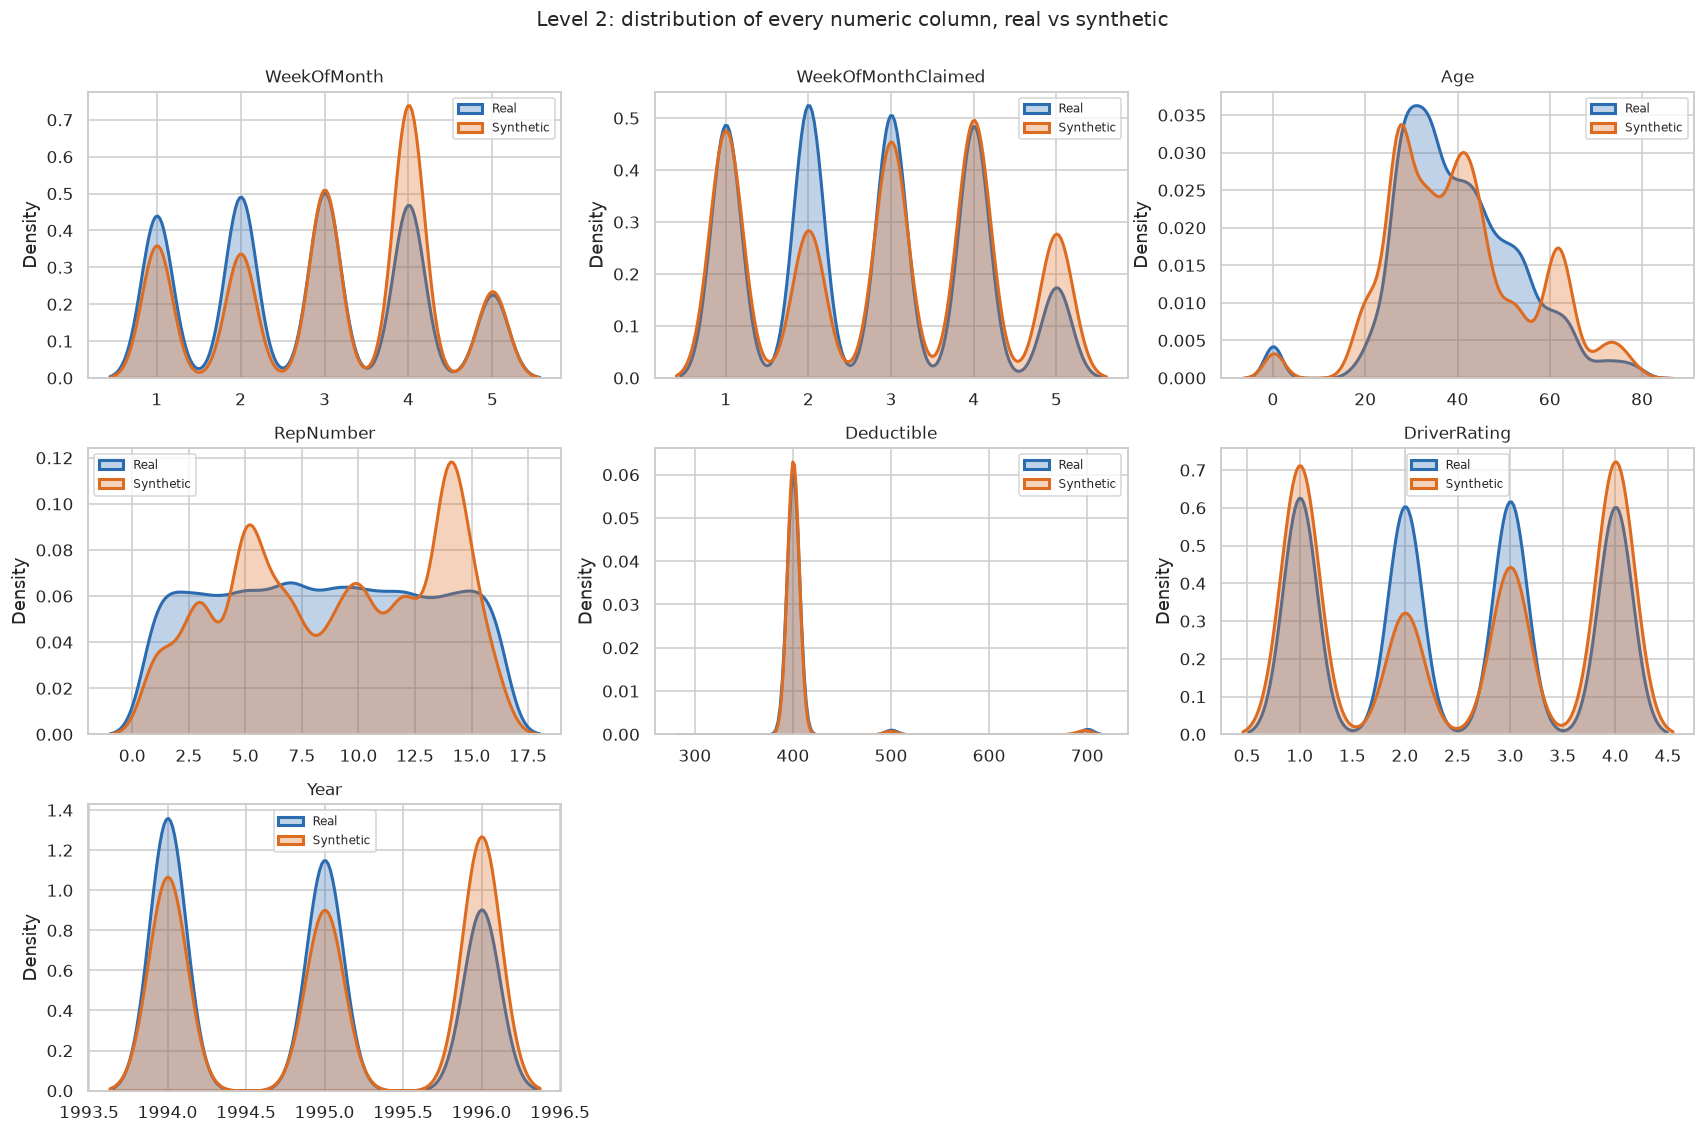

In [17]:
# Overlaid KDE plots, one panel per numeric column, real against synthetic.
n = len(NUMERIC_COLS)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, NUMERIC_COLS):
    sns.kdeplot(real[c], ax=ax, label="Real", color=C_REAL, fill=True, alpha=0.30, linewidth=2)
    sns.kdeplot(synth[c], ax=ax, label="Synthetic", color=C_SYNTH, fill=True, alpha=0.30, linewidth=2)
    ax.set_title(c, fontsize=11)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

# Hide any unused panels
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Level 2: distribution of every numeric column, real vs synthetic", y=1.005, fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L2_kde_numeric.png")
plt.show()

Where the blue and orange shapes sit on top of each other, CTGAN has
learned that column. Where orange is shifted, flatter or missing a peak that blue has, it has not.

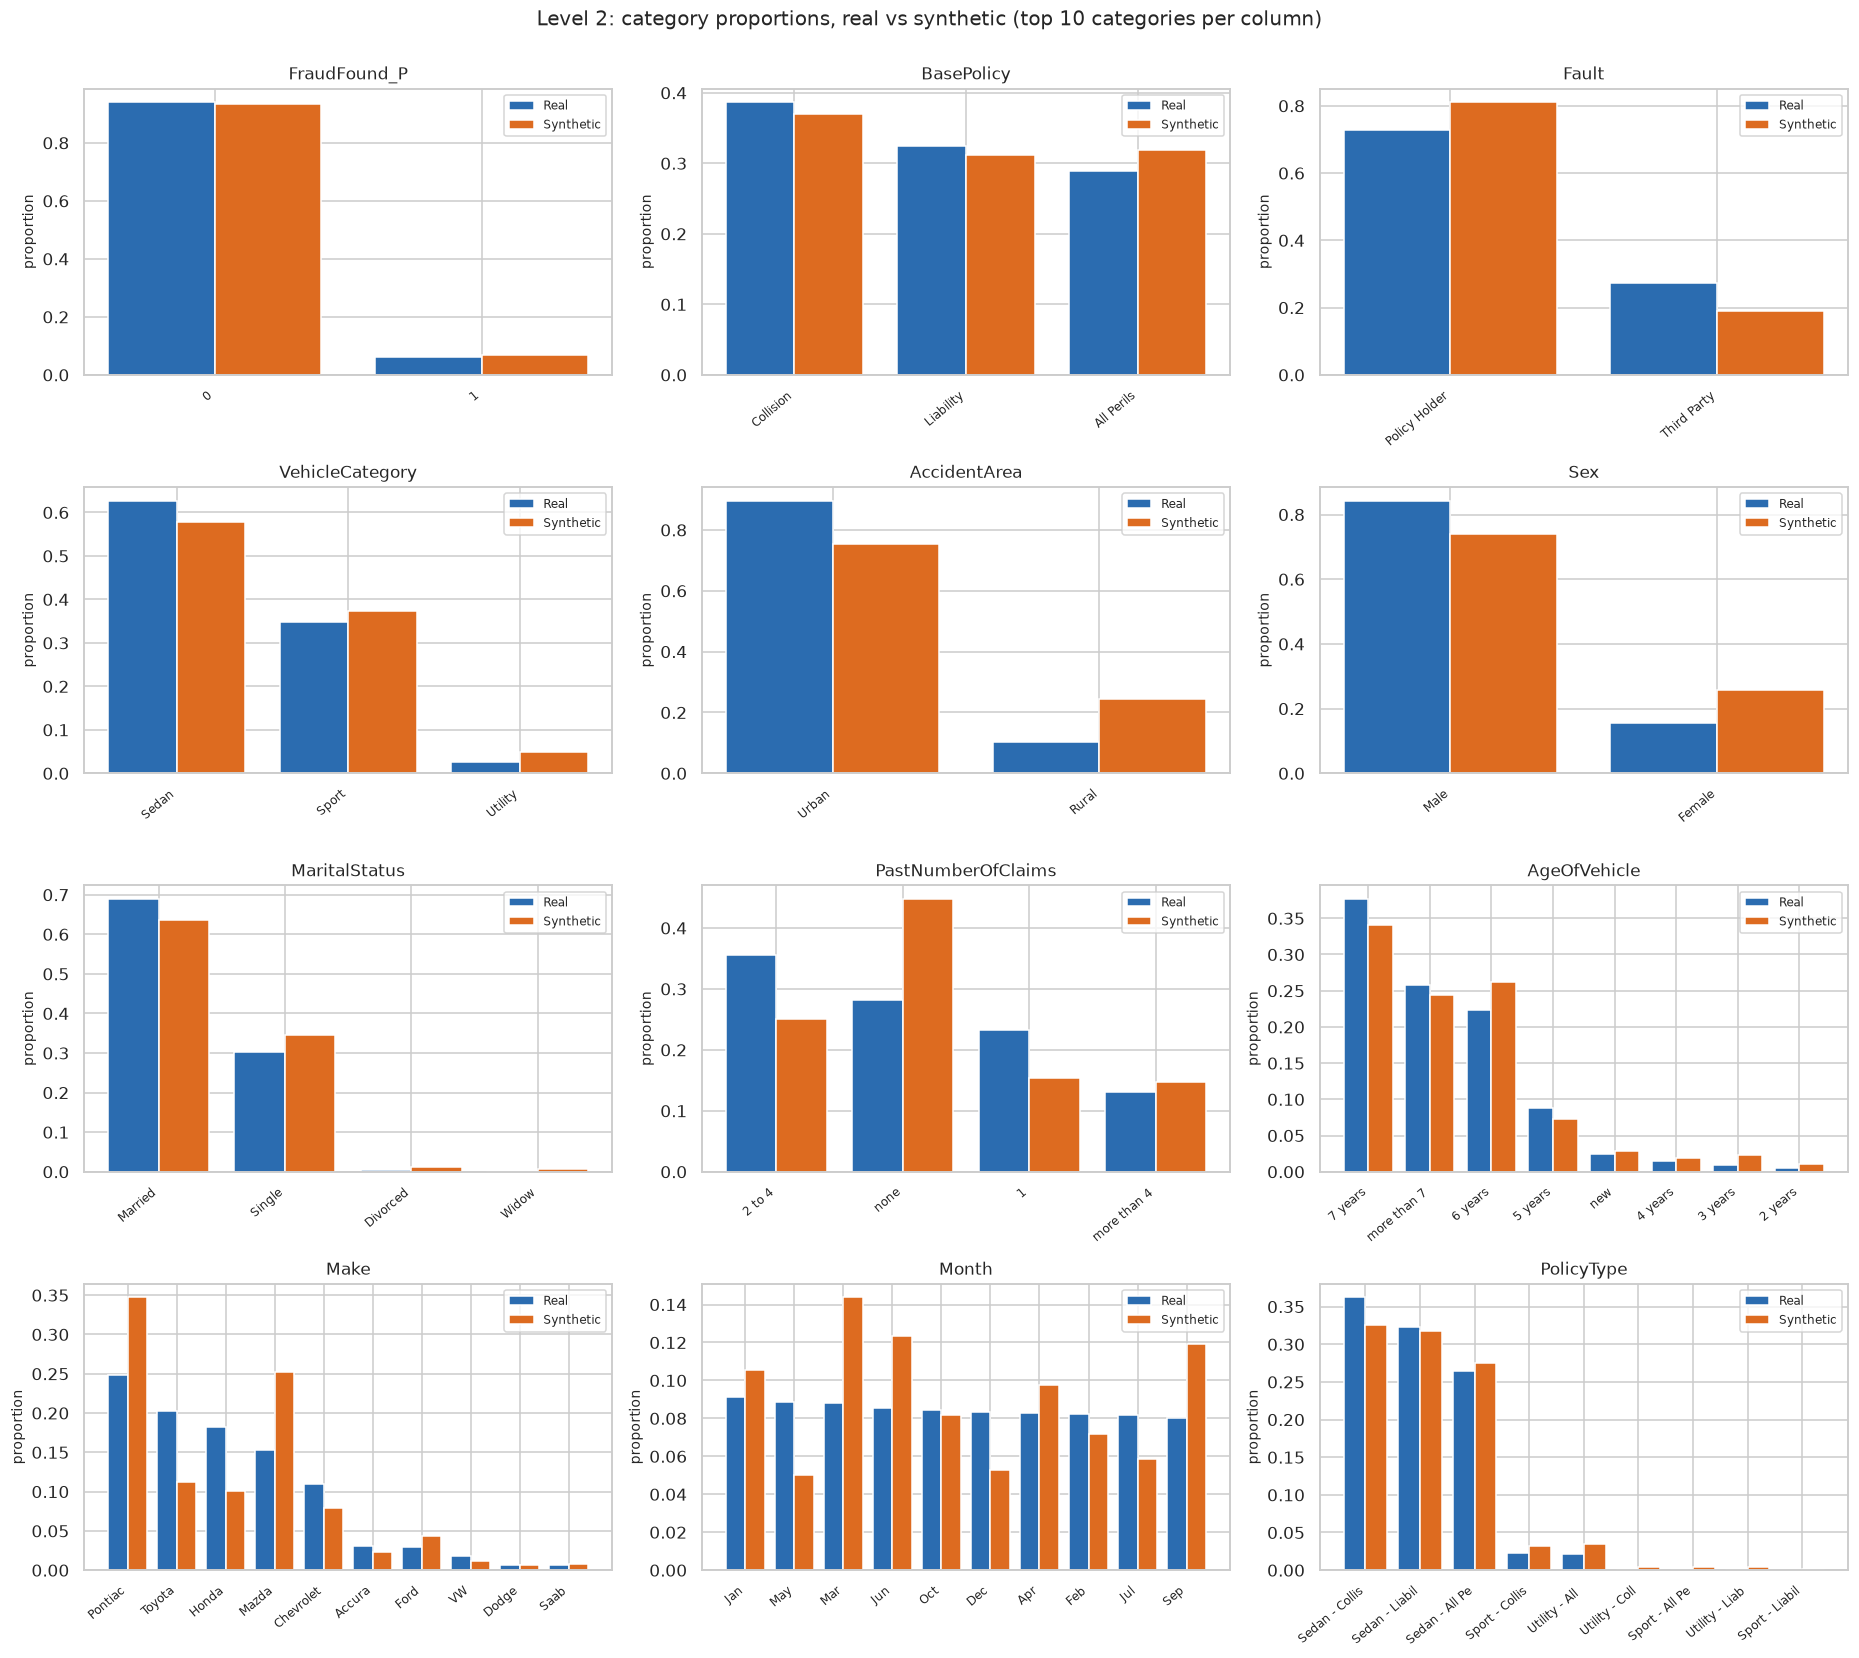

In [18]:
# Bar charts for the categorical columns. We show the proportion of claims in each category so
# that real and synthetic are directly comparable.
def cat_compare_frame(col):
    r = real[col].value_counts(normalize=True).rename("Real")
    s = synth[col].value_counts(normalize=True).rename("Synthetic")
    return pd.concat([r, s], axis=1).fillna(0.0).sort_values("Real", ascending=False)

# Key categorical columns: the target, the strongest known fraud signals, and the widest column.
KEY_CATS = [TARGET, "BasePolicy", "Fault", "VehicleCategory", "AccidentArea", "Sex",
            "MaritalStatus", "PastNumberOfClaims", "AgeOfVehicle", "Make", "Month", "PolicyType"]

fig, axes = plt.subplots(4, 3, figsize=(17, 15))
axes = axes.ravel()
for ax, col in zip(axes, KEY_CATS):
    cf = cat_compare_frame(col)
    if len(cf) > 10:                   
        cf = cf.head(10)
    x = np.arange(len(cf))
    w = 0.4
    ax.bar(x - w / 2, cf["Real"], w, label="Real", color=C_REAL)
    ax.bar(x + w / 2, cf["Synthetic"], w, label="Synthetic", color=C_SYNTH)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i)[:14] for i in cf.index], rotation=40, ha="right", fontsize=8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("proportion", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Level 2: category proportions, real vs synthetic (top 10 categories per column)",
             y=1.002, fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L2_bars_categorical.png")
plt.show()

In [19]:
# Quantify what the bar charts show: Total Variation Distance per categorical column.
tvd_rows = []
for c in CATEGORICAL_COLS:
    cats = sorted(set(real[c].unique()) | set(synth[c].unique()), key=str)
    p = real[c].value_counts(normalize=True).reindex(cats).fillna(0).values
    q = synth[c].value_counts(normalize=True).reindex(cats).fillna(0).values
    tvd = 0.5 * np.abs(p - q).sum()
    missing = sorted(set(real[c].unique()) - set(synth[c].unique()), key=str)
    tvd_rows.append({
        "column": c,
        "n_categories_real": real[c].nunique(),
        "n_categories_synth": synth[c].nunique(),
        "categories_missed": len(missing),
        "TVD": round(float(tvd), 4),
    })

tvd_df = pd.DataFrame(tvd_rows).sort_values("TVD", ascending=False)
print("Total Variation Distance per categorical column (lower is better):")
print(tvd_df.to_string(index=False))
print()
print(f"Mean TVD across all {len(CATEGORICAL_COLS)} categorical columns: {tvd_df['TVD'].mean():.4f}")
print(f"Worst column: {tvd_df.iloc[0]['column']} (TVD = {tvd_df.iloc[0]['TVD']:.4f})")
print(f"Columns where CTGAN missed at least one real category: {int((tvd_df['categories_missed'] > 0).sum())}")

RESULTS["level2_tvd"] = tvd_df.to_dict("records")
RESULTS["level2_mean_tvd"] = float(tvd_df["TVD"].mean())

Total Variation Distance per categorical column (lower is better):
              column  n_categories_real  n_categories_synth  categories_missed    TVD
    DayOfWeekClaimed                  8                   8                  0 0.2817
                Make                 19                  19                  0 0.2167
  PastNumberOfClaims                  4                   4                  0 0.1825
           DayOfWeek                  7                   7                  0 0.1704
        VehiclePrice                  6                   6                  0 0.1680
               Month                 12                  12                  0 0.1606
 NumberOfSuppliments                  4                   4                  0 0.1593
   AgeOfPolicyHolder                  9                   9                  0 0.1438
        AccidentArea                  2                   2                  0 0.1412
        MonthClaimed                 13                  13              

 *Total Variation Distance (TVD)* is a single number between 0 and 1 summarising
how far apart two sets of category proportions are. A TVD of 0.05 means that, at worst, the two
datasets disagree by 5 percentage points about how much probability sits in any group of
categories. Below roughly 0.05 the difference is hard to see by eye; above about 0.15 the column
is visibly distorted.

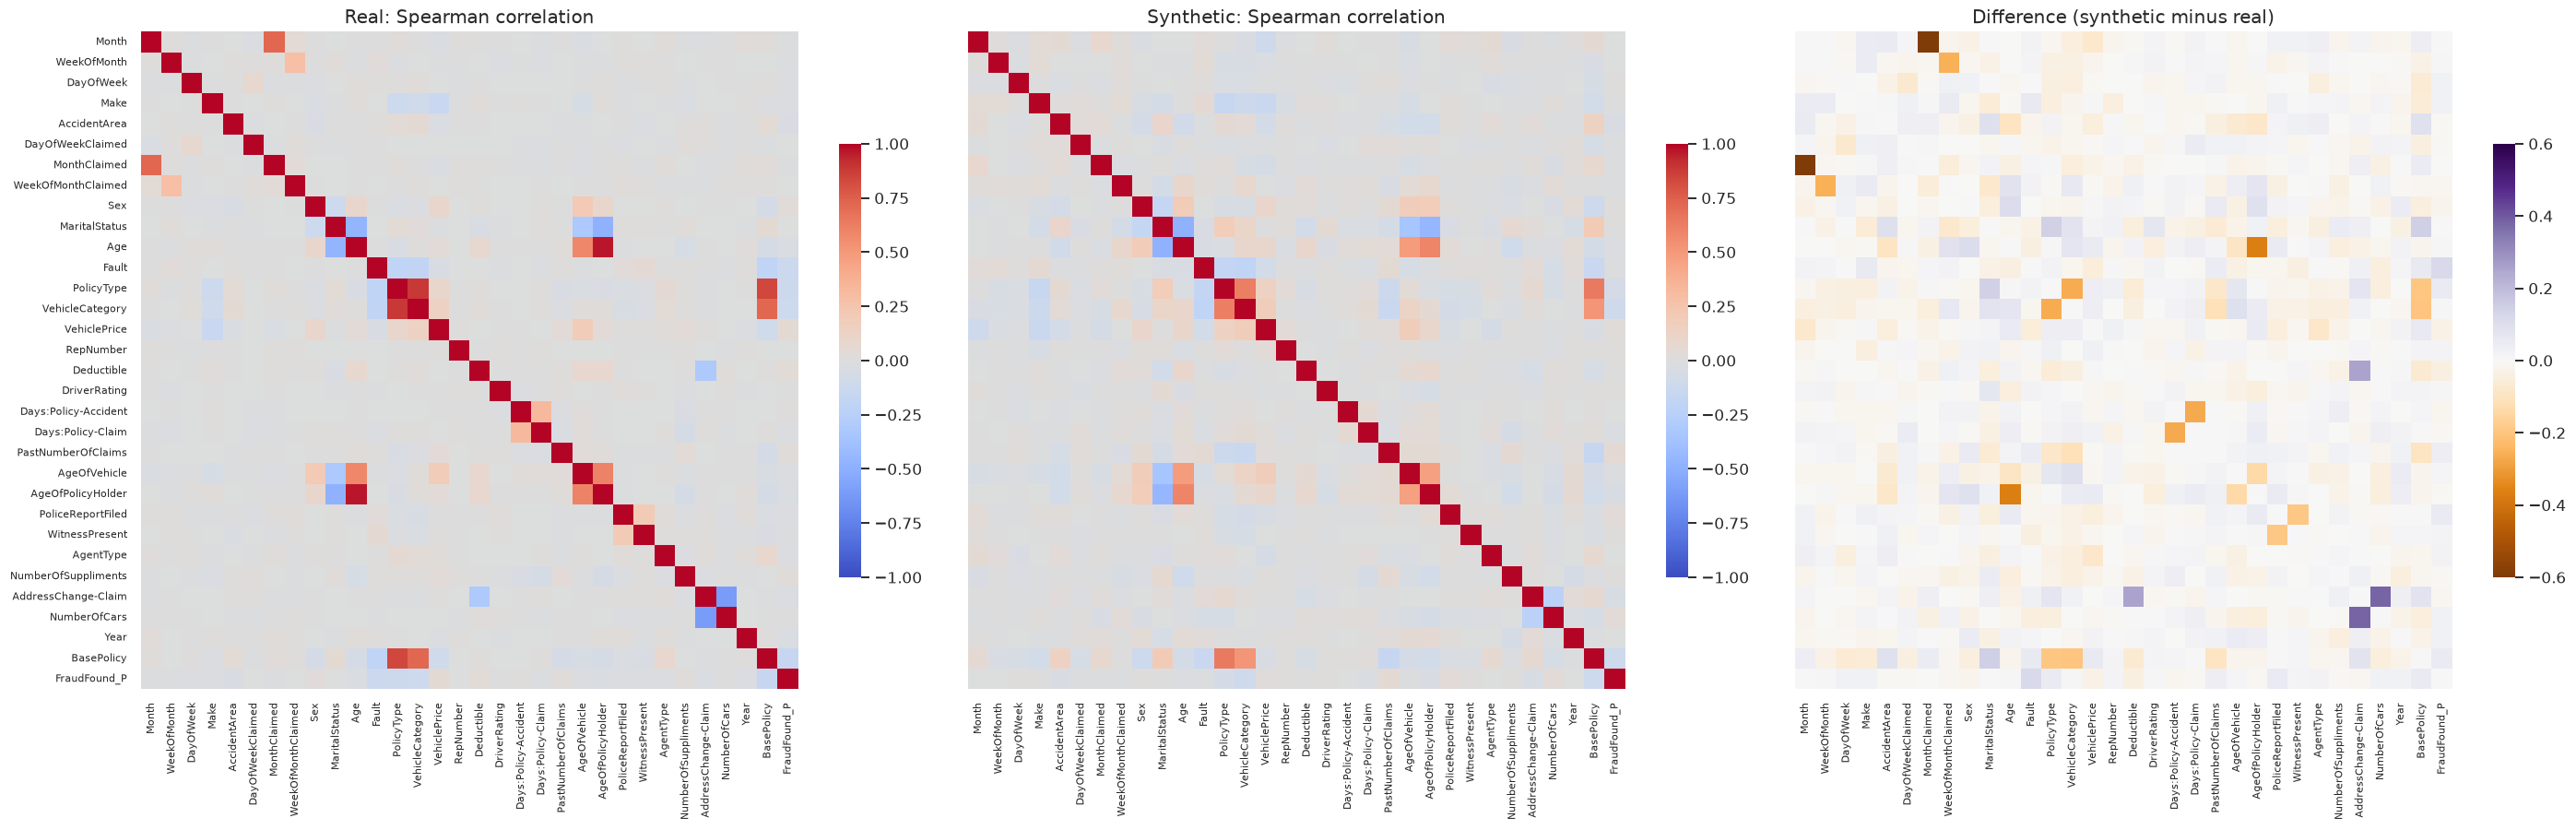

In [20]:
# Correlation heatmaps. Correlation needs numbers, so we encode every categorical column with a
# single integer code first. The encoder is fitted on the real data and reused for the synthetic
# data so both are mapped identically. We use Spearman correlation, which measures monotonic
# association by rank and is more appropriate here than Pearson because most columns are ordinal
# or coded categories rather than true continuous quantities.
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(real[CATEGORICAL_COLS].astype(str))

def encode_all(df):
    out = df.copy()
    out[CATEGORICAL_COLS] = enc.transform(df[CATEGORICAL_COLS].astype(str))
    return out.astype(float)

real_enc = encode_all(real)
synth_enc = encode_all(synth)

corr_real = real_enc.corr(method="spearman")
corr_synth = synth_enc.corr(method="spearman")
corr_diff = corr_synth - corr_real

fig, axes = plt.subplots(1, 3, figsize=(26, 8))
sns.heatmap(corr_real, ax=axes[0], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
axes[0].set_title("Real: Spearman correlation", fontsize=13)

sns.heatmap(corr_synth, ax=axes[1], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=False)
axes[1].set_title("Synthetic: Spearman correlation", fontsize=13)

sns.heatmap(corr_diff, ax=axes[2], cmap="PuOr", center=0, vmin=-0.6, vmax=0.6,
            square=True, cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=False)
axes[2].set_title("Difference (synthetic minus real)", fontsize=13)

for ax in axes:
    ax.tick_params(axis="x", labelsize=7, rotation=90)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L2_correlation_heatmaps.png")
plt.show()

In [21]:
# Reduce the difference heatmap to numbers we can quote.
# Take only the lower triangle so each column pair is counted once.
mask = np.tril(np.ones(corr_diff.shape), k=-1).astype(bool)
diffs = np.abs(corr_diff.values[mask])

print("Correlation preservation across all column pairs")
print("=" * 55)
print(f"Number of column pairs compared : {len(diffs):,}")
print(f"Mean absolute correlation error : {diffs.mean():.4f}")
print(f"Median absolute error           : {np.median(diffs):.4f}")
print(f"90th percentile absolute error  : {np.percentile(diffs, 90):.4f}")
print(f"Maximum absolute error          : {diffs.max():.4f}")
print()

# Which specific pairs moved the most?
pairs = []
cols = list(corr_diff.columns)
for i in range(len(cols)):
    for j in range(i):
        pairs.append({
            "col_a": cols[i], "col_b": cols[j],
            "real_corr": round(float(corr_real.values[i, j]), 3),
            "synth_corr": round(float(corr_synth.values[i, j]), 3),
            "abs_error": round(float(abs(corr_diff.values[i, j])), 3),
        })
pairs_df = pd.DataFrame(pairs).sort_values("abs_error", ascending=False)
print("10 worst preserved column pairs:")
print(pairs_df.head(10).to_string(index=False))

RESULTS["level2_corr_mean_abs_err"] = float(diffs.mean())
RESULTS["level2_corr_max_abs_err"] = float(diffs.max())
RESULTS["level2_corr_p90_abs_err"] = float(np.percentile(diffs, 90))
RESULTS["level2_worst_pairs"] = pairs_df.head(10).to_dict("records")

Correlation preservation across all column pairs
Number of column pairs compared : 496
Mean absolute correlation error : 0.0296
Median absolute error           : 0.0181
90th percentile absolute error  : 0.0537
Maximum absolute error          : 0.6451

10 worst preserved column pairs:
              col_a                col_b  real_corr  synth_corr  abs_error
       MonthClaimed                Month      0.726       0.081      0.645
       NumberOfCars  AddressChange-Claim     -0.611      -0.227      0.384
  AgeOfPolicyHolder                  Age      0.963       0.597      0.366
  Days:Policy-Claim Days:Policy-Accident      0.326       0.055      0.272
    VehicleCategory           PolicyType      0.889       0.624      0.265
AddressChange-Claim           Deductible     -0.305      -0.050      0.256
 WeekOfMonthClaimed          WeekOfMonth      0.283       0.029      0.254
         BasePolicy      VehicleCategory      0.723       0.523      0.200
         BasePolicy           PolicyType

In [22]:
# The correlations that matter most for this task are the ones involving the fraud target,
# because those are the signals a fraud model will try to learn.
tgt_real = corr_real[TARGET].drop(TARGET)
tgt_synth = corr_synth[TARGET].drop(TARGET)
tgt_cmp = pd.DataFrame({
    "real_corr_with_fraud": tgt_real.round(3),
    "synth_corr_with_fraud": tgt_synth.round(3),
    "abs_error": (tgt_synth - tgt_real).abs().round(3),
}).sort_values("real_corr_with_fraud", key=abs, ascending=False)

print("Correlation of each feature with FraudFound_P, strongest real signals first:")
print(tgt_cmp.head(12).to_string())
print()
print(f"Mean absolute error on fraud correlations: {tgt_cmp['abs_error'].mean():.4f}")

sign_flips = tgt_cmp[(np.sign(tgt_cmp["real_corr_with_fraud"]) != np.sign(tgt_cmp["synth_corr_with_fraud"]))
                     & (tgt_cmp["real_corr_with_fraud"].abs() > 0.03)]
print(f"\nFeatures with a meaningful real signal whose direction flipped in synthetic: {len(sign_flips)}")
if len(sign_flips):
    print(sign_flips.to_string())

RESULTS["level2_fraud_corr"] = tgt_cmp.reset_index().rename(columns={"index": "feature"}).to_dict("records")
RESULTS["level2_fraud_corr_mae"] = float(tgt_cmp["abs_error"].mean())
RESULTS["level2_fraud_sign_flips"] = int(len(sign_flips))

Correlation of each feature with FraudFound_P, strongest real signals first:
                     real_corr_with_fraud  synth_corr_with_fraud  abs_error
BasePolicy                         -0.158                 -0.110      0.048
Fault                              -0.131                 -0.014      0.117
PolicyType                         -0.117                 -0.066      0.051
VehicleCategory                    -0.114                 -0.105      0.009
VehiclePrice                        0.050                  0.020      0.029
Deductible                          0.041                  0.000      0.041
AccidentArea                       -0.033                 -0.039      0.005
Sex                                 0.030                  0.010      0.020
AddressChange-Claim                -0.030                 -0.040      0.010
AgeOfPolicyHolder                  -0.028                 -0.035      0.007
Age                                -0.027                 -0.022      0.005
Year       

A correlation error is abstract. To make it concrete, we check two pairs of columns that describe
overlapping information about the same claim, and ask how often the two fields actually agree
inside a single record:

1. `PolicyType` reads like `"Sedan - Collision"`, which is `VehicleCategory` and `BasePolicy`
   joined together. So `PolicyType` should equal `"{VehicleCategory} - {BasePolicy}"`.
2. `AgeOfPolicyHolder` is an age band such as `"31 to 35"`, so the numeric `Age` on the same claim
   should fall inside that band.

**The real data is the benchmark here, not 100%.** This Kaggle file has its own quality problems and
these two rules do not hold on every real claim either. What matters is whether the synthetic data
is as internally coherent as the real data, so we compare the two rates directly.

In [23]:
import re

def policytype_agreement(df):
    """Share of claims where PolicyType matches VehicleCategory and BasePolicy."""
    expected = df["VehicleCategory"].astype(str) + " - " + df["BasePolicy"].astype(str)
    return float((expected == df["PolicyType"]).mean())

def age_band_agreement(df):
    """Share of claims where the numeric Age falls inside the AgeOfPolicyHolder band.
    Age = 0 is the known placeholder, so those rows are excluded rather than counted as failures."""
    def check(row):
        band, age = str(row["AgeOfPolicyHolder"]), row["Age"]
        if age == 0:
            return None
        m = re.match(r"(\d+)\s*to\s*(\d+)", band)
        if m:
            return int(m.group(1)) <= age <= int(m.group(2))
        m = re.match(r"over\s*(\d+)", band)
        if m:
            return age > int(m.group(1))
        return None
    s = df.apply(check, axis=1).dropna()
    return float(s.mean()), int(len(s))

pt_real, pt_synth = policytype_agreement(real), policytype_agreement(synth)
ab_real, n_real = age_band_agreement(real)
ab_synth, n_synth = age_band_agreement(synth)

coherence = pd.DataFrame([
    {"consistency rule": "PolicyType == 'VehicleCategory - BasePolicy'",
     "real": f"{pt_real:.2%}", "synthetic": f"{pt_synth:.2%}",
     "drop (pp)": round((pt_real - pt_synth) * 100, 1),
     "retained": f"{pt_synth/pt_real:.1%}"},
    {"consistency rule": "Age falls inside the AgeOfPolicyHolder band",
     "real": f"{ab_real:.2%}", "synthetic": f"{ab_synth:.2%}",
     "drop (pp)": round((ab_real - ab_synth) * 100, 1),
     "retained": f"{ab_synth/ab_real:.1%}"},
])
print("Record level coherence: do related fields agree within the same claim?")
print("=" * 96)
print(coherence.to_string(index=False))
print()
print(f"Age band rule evaluated on {n_real:,} real and {n_synth:,} synthetic claims "
      f"(Age = 0 placeholder rows excluded).")

RESULTS["level2_coherence"] = coherence.to_dict("records")
RESULTS["level2_policytype_real"] = pt_real
RESULTS["level2_policytype_synth"] = pt_synth
RESULTS["level2_ageband_real"] = ab_real
RESULTS["level2_ageband_synth"] = ab_synth

Record level coherence: do related fields agree within the same claim?
                            consistency rule   real synthetic  drop (pp) retained
PolicyType == 'VehicleCategory - BasePolicy' 67.66%    50.61%       17.0    74.8%
 Age falls inside the AgeOfPolicyHolder band 54.16%    25.88%       28.3    47.8%

Age band rule evaluated on 15,100 real and 15,183 synthetic claims (Age = 0 placeholder rows excluded).


The real data obeys these rules only part of the time, so the bar is not
perfection. But the synthetic data agrees with itself noticeably less often than the real data
does. This is what a correlation error of 0.3 or 0.6 between two related columns actually looks
like at the level of an individual claim: records where the policy type does not match the vehicle
and the base policy, or where a claimant's numeric age sits outside their own stated age band.

For a fraud model this matters, because such combinations are precisely the kind of internal
inconsistency a human investigator or a rule based system would treat as suspicious. A model
trained on this data would see inconsistent records scattered through both the fraudulent and the
legitimate class, and would learn that they carry no signal.

In [24]:
mean_tvd = RESULTS["level2_mean_tvd"]
corr_mae = RESULTS["level2_corr_mean_abs_err"]
fraud_mae = RESULTS["level2_fraud_corr_mae"]

checks = {
    "Category proportions (mean TVD < 0.10)": mean_tvd < 0.10,
    "Correlation structure (mean abs error < 0.10)": corr_mae < 0.10,
    "Fraud signal strength (mean abs error < 0.05)": fraud_mae < 0.05,
}

print("LEVEL 2 RESULT")
print("=" * 60)
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

print()
print(f"  mean TVD                        = {mean_tvd:.4f}")
print(f"  mean abs correlation error      = {corr_mae:.4f}")
print(f"  mean abs fraud-correlation error= {fraud_mae:.4f}")
print()
level2_pass = all(checks.values())
print(f"VERDICT: {'PASS' if level2_pass else 'WEAK'}")

RESULTS["level2_pass"] = bool(level2_pass)
RESULTS["level2_checks"] = {k: bool(v) for k, v in checks.items()}

LEVEL 2 RESULT
  FAIL  Category proportions (mean TVD < 0.10)
  PASS  Correlation structure (mean abs error < 0.10)
  PASS  Fraud signal strength (mean abs error < 0.05)

  mean TVD                        = 0.1010
  mean abs correlation error      = 0.0296
  mean abs fraud-correlation error= 0.0215

VERDICT: WEAK


---
# Level 3. Statistical Tests

Levels 1 and 2 were descriptive. Level 3 applies formal tests that give a yes/no answer to the
question "can we *detect* that these two samples came from different distributions?"


- **Kolmogorov-Smirnov (KS) test**, for numeric columns. The KS *statistic* is the largest gap
  between the two cumulative distributions, on a 0 to 1 scale where 0 means identical. The
  *p-value* is the probability of seeing a gap that large if the two samples really did come from
  the same distribution.
- **Chi-squared test**, for categorical columns. It compares the observed counts in each category
  against the counts we would expect if real and synthetic followed the same distribution.
- **Wasserstein distance** (also called earth mover's distance), for numeric columns. It is the
  average amount you would have to shift values to turn one distribution into the other, measured
  in the column's own units. Unlike the KS test it does not depend on sample size, so it tells you
  *how big* the difference is rather than only whether it is detectable.

With 15,420 rows on each side, these tests are
extremely sensitive. A difference far too small to matter in practice will still produce a p-value
below 0.05. So a low p-value here means "the distributions differ detectably", not "the synthetic
data is unusable". That is exactly why we report the effect sizes (KS statistic and Wasserstein
distance) alongside the p-values, and why we read them together.

In [25]:
# KS test and Wasserstein distance for every numeric column
ALPHA = 0.05
num_rows = []
for c in NUMERIC_COLS:
    ks_stat, ks_p = ks_2samp(real[c], synth[c])
    wd = wasserstein_distance(real[c], synth[c])
    rng = real[c].max() - real[c].min()
    # The framework's Level 3c normalisation: divide by the real column's standard deviation,
    # which is what makes the score comparable across features on different scales. Dividing
    # by the range instead is NOT equivalent - the range is several times sigma on every
    # column here, so it shrinks every score and would let all seven clear the 0.15 gate.
    w_sigma = float(wd / real[c].std())
    num_rows.append({
        "column": c,
        "test": "KS",
        "statistic": round(float(ks_stat), 4),
        "p_value": float(ks_p),
        "wasserstein": round(float(wd), 4),
        "wasserstein_/_sigma": round(w_sigma, 4),
        "wasserstein_band": ("Excellent" if w_sigma < 0.05
                             else "Acceptable" if w_sigma <= 0.15 else "Poor - review"),
        "wasserstein_%_of_range": round(float(wd / rng * 100), 2),
        "same_dist_at_5%": bool(ks_p > ALPHA),
    })

num_tests = pd.DataFrame(num_rows)
num_tests["p_value_fmt"] = num_tests["p_value"].apply(
    lambda p: "< 1e-16" if p < 1e-16 else f"{p:.3e}"
)

def ks_interpret(row):
    d = row["statistic"]
    if row["same_dist_at_5%"]:
        return "No detectable difference"
    if d < 0.05:
        return "Detectable but negligible gap"
    if d < 0.10:
        return "Small gap"
    if d < 0.20:
        return "Moderate gap"
    return "Large gap"

num_tests["interpretation"] = num_tests.apply(ks_interpret, axis=1)

print("NUMERIC COLUMNS: KS test and Wasserstein distance")
print("=" * 100)
print(num_tests[["column", "statistic", "p_value_fmt", "wasserstein",
                 "wasserstein_%_of_range", "same_dist_at_5%", "interpretation"]].to_string(index=False))

RESULTS["level3_numeric"] = num_tests.drop(columns=["p_value_fmt"]).to_dict("records")

NUMERIC COLUMNS: KS test and Wasserstein distance
            column  statistic p_value_fmt  wasserstein  wasserstein_%_of_range  same_dist_at_5%           interpretation
       WeekOfMonth     0.1204     < 1e-16       0.2822                    7.06            False             Moderate gap
WeekOfMonthClaimed     0.0863     < 1e-16       0.2442                    6.11            False                Small gap
               Age     0.0787     < 1e-16       1.6922                    2.12            False                Small gap
         RepNumber     0.0763     < 1e-16       0.6236                    4.16            False                Small gap
        Deductible     0.0119   2.258e-01       0.8204                    0.21             True No detectable difference
      DriverRating     0.0826     < 1e-16       0.1827                    6.09            False                Small gap
              Year     0.1270     < 1e-16       0.1957                    9.78            False        

`KS statistic`: the biggest vertical gap between the
two cumulative curves. Think of it as "at the worst point, the two datasets disagree by this
fraction about what share of claims fall below some value". Under 0.05 is negligible, 0.05 to 0.10
is small, above 0.20 is a real problem.

`wasserstein_%_of_range` re-expresses the Wasserstein distance as a percentage of the column's
span, which makes columns on different scales comparable. A value of 2% on `Age` means the
average claim age would need to move by about 2% of the 0 to 80 range, roughly 1.6 years, to make
the distributions match.

In [26]:
# Chi-squared test for every categorical column.
cat_rows = []
for c in CATEGORICAL_COLS:
    cats = sorted(set(real[c].unique()) | set(synth[c].unique()), key=str)
    obs_r = real[c].value_counts().reindex(cats).fillna(0).values
    obs_s = synth[c].value_counts().reindex(cats).fillna(0).values
    table = np.vstack([obs_r, obs_s])

    # Drop any category that is empty in both datasets (all-zero column breaks the test)
    keep = table.sum(axis=0) > 0
    table = table[:, keep]

    chi2, p, dof, expected = chi2_contingency(table)

    # Cramer's V turns the chi-squared statistic into an effect size between 0 and 1,
    # so it can be compared across columns with different numbers of categories.
    n_total = table.sum()
    cramers_v = np.sqrt(chi2 / (n_total * (min(table.shape) - 1)))

    cat_rows.append({
        "column": c,
        "test": "Chi-squared",
        "n_categories": int(keep.sum()),
        "statistic": round(float(chi2), 2),
        "p_value": float(p),
        "dof": int(dof),
        "cramers_v": round(float(cramers_v), 4),
        "same_dist_at_5%": bool(p > ALPHA),
    })

cat_tests = pd.DataFrame(cat_rows)
cat_tests["p_value_fmt"] = cat_tests["p_value"].apply(
    lambda p: "< 1e-16" if p < 1e-16 else f"{p:.3e}"
)

def v_interpret(row):
    v = row["cramers_v"]
    if row["same_dist_at_5%"]:
        return "No detectable difference"
    if v < 0.05:
        return "Detectable but negligible"
    if v < 0.10:
        return "Small effect"
    if v < 0.20:
        return "Moderate effect"
    return "Large effect"

cat_tests["interpretation"] = cat_tests.apply(v_interpret, axis=1)
cat_tests = cat_tests.sort_values("cramers_v", ascending=False)

print("CATEGORICAL COLUMNS: Chi-squared test")
print("=" * 100)
print(cat_tests[["column", "n_categories", "statistic", "p_value_fmt", "cramers_v",
                 "same_dist_at_5%", "interpretation"]].to_string(index=False))

RESULTS["level3_categorical"] = cat_tests.drop(columns=["p_value_fmt"]).to_dict("records")

CATEGORICAL COLUMNS: Chi-squared test
              column  n_categories  statistic p_value_fmt  cramers_v  same_dist_at_5%            interpretation
    DayOfWeekClaimed             8    2675.72     < 1e-16     0.2946            False              Large effect
                Make            19    1564.77     < 1e-16     0.2253            False              Large effect
           DayOfWeek             7    1201.61     < 1e-16     0.1974            False           Moderate effect
  PastNumberOfClaims             4    1113.90     < 1e-16     0.1900            False           Moderate effect
        VehiclePrice             6    1085.04     < 1e-16     0.1876            False           Moderate effect
        AccidentArea             2    1067.18     < 1e-16     0.1860            False           Moderate effect
 NumberOfSuppliments             4    1065.46     < 1e-16     0.1859            False           Moderate effect
               Month            12     991.13     < 1e-16     0.17

### Levels 3a and 3b: two criteria, and why we decide on the second

**The framework's criterion** is `p > 0.05` on every column: if the test cannot reject the null
hypothesis that the two samples came from the same distribution, the column is aligned.

**The criterion we adopt** is the effect size: mean KS statistic below 0.10 for the numeric
columns, mean Cramer's V below 0.10 for the categorical ones, and no column showing a large effect.

The reason for adopting the second is a property of the test, not a preference about the result.
A p-value answers "is there *any* detectable difference?", and its power grows with sample size.
With 15,420 rows on each side these tests can detect differences far too small to matter. The
practical consequence is visible in this run: **not one of the 32 columns clears p > 0.05**, and
the largest p-value in the entire set is roughly 630 times smaller than the threshold. A criterion
that fails every column, including the ones whose distributions are visibly almost identical,
cannot rank columns or guide a decision. It has no resolution left.

Effect sizes do not have this problem. The KS statistic is the largest vertical gap between the two
cumulative distributions and Cramer's V is a correlation-like measure of association: both are
expressed on a fixed 0 to 1 scale and neither grows with sample size. They answer the question that
actually matters for a release decision, which is *how large* the difference is rather than whether
a large enough sample can detect it.

In [27]:
# Combine everything into the single Level 3 table the brief asks for.
combined = pd.concat([
    num_tests.assign(effect_size=num_tests["statistic"], effect_name="KS statistic")[
        ["column", "test", "statistic", "p_value", "effect_size", "effect_name",
         "same_dist_at_5%", "interpretation"]],
    cat_tests.assign(effect_size=cat_tests["cramers_v"], effect_name="Cramer's V")[
        ["column", "test", "statistic", "p_value", "effect_size", "effect_name",
         "same_dist_at_5%", "interpretation"]],
], ignore_index=True)
combined["p_value_fmt"] = combined["p_value"].apply(lambda p: "< 1e-16" if p < 1e-16 else f"{p:.3e}")

n_pass = int(combined["same_dist_at_5%"].sum())
n_total_cols = len(combined)
n_negligible = int(combined["interpretation"].str.contains("negligible|No detectable").sum())
n_large = int(combined["interpretation"].str.contains("Large").sum())
n_moderate = int(combined["interpretation"].str.contains("Moderate").sum())

print("LEVEL 3 RESULT")
print("=" * 60)
print(f"Columns tested                                  : {n_total_cols}")
print(f"Columns where no difference is detectable (p>.05): {n_pass}")
print(f"Columns with negligible or no practical gap     : {n_negligible}")
print(f"Columns with a moderate gap                     : {n_moderate}")
print(f"Columns with a large gap                        : {n_large}")
print()
print(f"Mean KS statistic across numeric columns : {num_tests['statistic'].mean():.4f}")
print(f"Max  KS statistic                        : {num_tests['statistic'].max():.4f} "
      f"({num_tests.loc[num_tests['statistic'].idxmax(), 'column']})")
print(f"Mean Cramer's V across categorical columns: {cat_tests['cramers_v'].mean():.4f}")
print(f"Max  Cramer's V                          : {cat_tests['cramers_v'].max():.4f} "
      f"({cat_tests.iloc[0]['column']})")
print()

ks_p_pass = int(num_tests["same_dist_at_5%"].sum())
chi_p_pass = int(cat_tests["same_dist_at_5%"].sum())
level3a_framework_pass = (ks_p_pass == len(num_tests))
level3b_framework_pass = (chi_p_pass == len(cat_tests))

level3ab_pass = ((num_tests["statistic"].mean() < 0.10)
                 and (cat_tests["cramers_v"].mean() < 0.10)
                 and (n_large == 0))

print("LEVELS 3a + 3b, BOTH CRITERIA")
print("-" * 60)
print(f"  Framework (p > 0.05 on every column):")
print(f"    3a KS        : {ks_p_pass}/{len(num_tests)} columns pass -> "
      f"{'PASS' if level3a_framework_pass else 'FAIL'}")
print(f"    3b Chi-square: {chi_p_pass}/{len(cat_tests)} columns pass -> "
      f"{'PASS' if level3b_framework_pass else 'FAIL'}")
print(f"  Effect size (ADOPTED): mean KS {num_tests['statistic'].mean():.4f} < 0.10, "
      f"mean V {cat_tests['cramers_v'].mean():.4f} < 0.10, large gaps {n_large} == 0")
print(f"    -> {'PASS' if level3ab_pass else 'FAIL'}")

# Level 3c. The framework's criterion, on the framework's normalisation.
n_poor = int((num_tests["wasserstein_/_sigma"] > 0.15).sum())
level3c_pass = (n_poor == 0)
print()
print("LEVEL 3c, FRAMEWORK CRITERION (Wasserstein / sigma(real) < 0.15 per feature)")
print("-" * 60)
print(num_tests[["column", "wasserstein", "wasserstein_/_sigma", "wasserstein_band"]]
      .sort_values("wasserstein_/_sigma", ascending=False).to_string(index=False))
print(f"\n  {n_poor}/{len(num_tests)} columns above the 0.15 line -> "
      f"{'PASS' if level3c_pass else 'FAIL'}")

level3_pass = level3ab_pass and level3c_pass
print()
print(f"LEVEL 3 OVERALL: {'PASS' if level3_pass else 'FAIL'}")

RESULTS["level3_n_tested"] = n_total_cols
RESULTS["level3_n_no_detectable_diff"] = n_pass
RESULTS["level3_n_large"] = n_large
RESULTS["level3_n_moderate"] = n_moderate
RESULTS["level3_mean_ks"] = float(num_tests["statistic"].mean())
RESULTS["level3_max_ks"] = float(num_tests["statistic"].max())
RESULTS["level3_mean_cramers_v"] = float(cat_tests["cramers_v"].mean())
RESULTS["level3_max_cramers_v"] = float(cat_tests["cramers_v"].max())
RESULTS["level3_pass"] = bool(level3_pass)
RESULTS["level3a_ks_p_pass_count"] = ks_p_pass
RESULTS["level3b_chi_p_pass_count"] = chi_p_pass
RESULTS["level3a_framework_pass"] = bool(level3a_framework_pass)
RESULTS["level3b_framework_pass"] = bool(level3b_framework_pass)
RESULTS["level3ab_pass"] = bool(level3ab_pass)
RESULTS["level3c_pass"] = bool(level3c_pass)
RESULTS["level3c_n_poor"] = n_poor
RESULTS["level3c_max_w_sigma"] = float(num_tests["wasserstein_/_sigma"].max())
RESULTS["level3c_mean_w_sigma"] = float(num_tests["wasserstein_/_sigma"].mean())

LEVEL 3 RESULT
Columns tested                                  : 32
Columns where no difference is detectable (p>.05): 1
Columns with negligible or no practical gap     : 3
Columns with a moderate gap                     : 15
Columns with a large gap                        : 2

Mean KS statistic across numeric columns : 0.0833
Max  KS statistic                        : 0.1270 (Year)
Mean Cramer's V across categorical columns: 0.1326
Max  Cramer's V                          : 0.2946 (DayOfWeekClaimed)

LEVELS 3a + 3b, BOTH CRITERIA
------------------------------------------------------------
  Framework (p > 0.05 on every column):
    3a KS        : 1/7 columns pass -> FAIL
    3b Chi-square: 0/25 columns pass -> FAIL
  Effect size (ADOPTED): mean KS 0.0833 < 0.10, mean V 0.1326 < 0.10, large gaps 2 == 0
    -> FAIL

LEVEL 3c, FRAMEWORK CRITERION (Wasserstein / sigma(real) < 0.15 per feature)
------------------------------------------------------------
            column  wasserstein  w

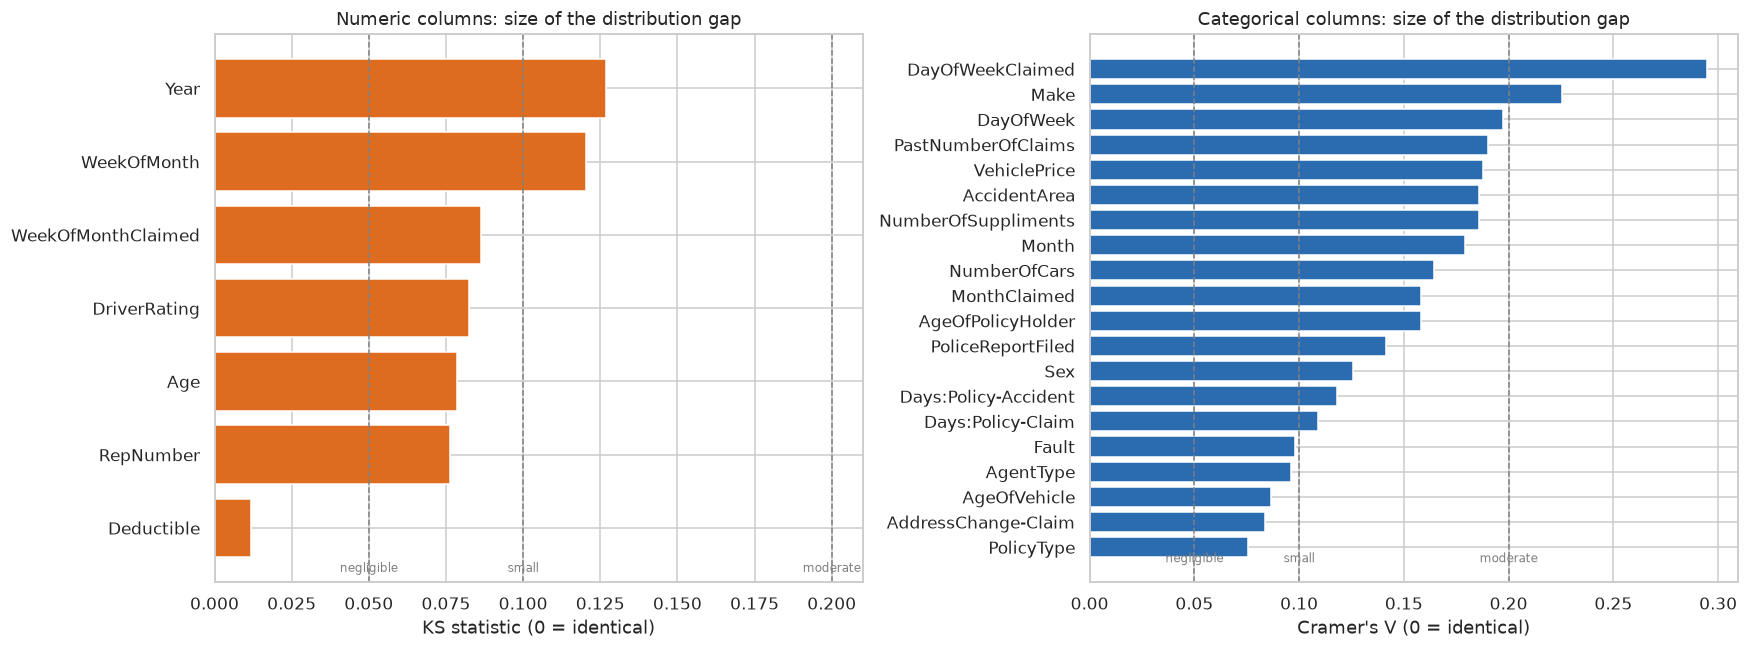

In [28]:
# Visualise the effect sizes so the pattern is easy to see at a glance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

d = num_tests.sort_values("statistic")
axes[0].barh(d["column"], d["statistic"], color=C_SYNTH)
for t, lab in [(0.05, "negligible"), (0.10, "small"), (0.20, "moderate")]:
    axes[0].axvline(t, color="grey", ls="--", lw=1)
    axes[0].text(t, -0.6, lab, fontsize=8, ha="center", color="grey")
axes[0].set_xlabel("KS statistic (0 = identical)")
axes[0].set_title("Numeric columns: size of the distribution gap")

d2 = cat_tests.sort_values("cramers_v").tail(20)
axes[1].barh(d2["column"], d2["cramers_v"], color=C_REAL)
for t, lab in [(0.05, "negligible"), (0.10, "small"), (0.20, "moderate")]:
    axes[1].axvline(t, color="grey", ls="--", lw=1)
    axes[1].text(t, -0.6, lab, fontsize=8, ha="center", color="grey")
axes[1].set_xlabel("Cramer's V (0 = identical)")
axes[1].set_title("Categorical columns: size of the distribution gap")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L3_effect_sizes.png")
plt.show()

---
# Level 4. Machine Learning Utility (TSTR)

This is the level that decides whether the synthetic data is actually *useful*.

The design:

1. Split the **real** data into a training set (70%) and a held-out test set (30%), keeping the
   fraud rate the same in both halves.
2. **TRTR** (Train Real, Test Real) is the baseline: fit a Random Forest on the real training set
   and score it on the real test set. This is how good the model can possibly be.
3. **TSTR** (Train Synthetic, Test Real) is the experiment: fit the *same* model on synthetic
   claims only, and score it on the *same* real test set.
4. Compare. If TSTR lands close to TRTR, the synthetic data carries the real fraud signal. If TSTR
   collapses, it does not.

*Accuracy* is the share of all claims classified correctly.

*Precision* is, of the claims we flagged as fraud, the share that really were fraud. 

*Recall* is, of all the real fraud, the share we managed to catch. *F1* is the harmonic mean of precision and
recall, a single balanced score. 

*ROC-AUC* is the probability that the model gives a randomly chosen fraudulent claim a higher risk score than a randomly chosen legitimate one, where 0.5 is a
coin flip and 1.0 is perfect ranking.

In [29]:
# Split the real data. Stratifying on the target keeps the 6% fraud rate in both halves
X_real = real.drop(columns=[TARGET])
y_real = real[TARGET]

X_tr_real, X_te_real, y_tr_real, y_te_real = train_test_split(
    X_real, y_real, test_size=0.30, random_state=SEED, stratify=y_real
)

print(f"Real training set : {X_tr_real.shape[0]:,} claims, {y_tr_real.sum():,} fraud ({y_tr_real.mean():.2%})")
print(f"Real test set     : {X_te_real.shape[0]:,} claims, {y_te_real.sum():,} fraud ({y_te_real.mean():.2%})")
print()

# For a fair comparison, train the synthetic model on the same number of rows as the real one.
# Otherwise TSTR would get an unfair advantage simply from having more data.
synth_train = synth.sample(n=len(X_tr_real), random_state=SEED)
X_tr_synth = synth_train.drop(columns=[TARGET])
y_tr_synth = synth_train[TARGET]

print(f"Synthetic training set: {X_tr_synth.shape[0]:,} claims, {y_tr_synth.sum():,} fraud ({y_tr_synth.mean():.2%})")
print()
print("Note the fraud counts. The synthetic training set carries "
      f"{y_tr_synth.sum():,} fraud examples against {y_tr_real.sum():,} in the real one, "
      f"a ratio of {y_tr_synth.sum()/y_tr_real.sum():.2f}x.")

RESULTS["l4_real_train_n"] = int(X_tr_real.shape[0])
RESULTS["l4_real_test_n"] = int(X_te_real.shape[0])
RESULTS["l4_real_train_fraud"] = int(y_tr_real.sum())
RESULTS["l4_real_test_fraud"] = int(y_te_real.sum())
RESULTS["l4_synth_train_fraud"] = int(y_tr_synth.sum())

Real training set : 10,794 claims, 646 fraud (5.98%)
Real test set     : 4,626 claims, 277 fraud (5.99%)

Synthetic training set: 10,794 claims, 726 fraud (6.73%)

Note the fraud counts. The synthetic training set carries 726 fraud examples against 646 in the real one, a ratio of 1.12x.


In [30]:
# Encode features identically for every model. The encoder is fitted on the REAL feature values,
# so real and synthetic rows are mapped into exactly the same feature space and the two models
# are genuinely comparable. Unseen categories map to -1, though CTGAN can only emit categories
# it saw in training so this should not trigger.
FEATURE_CATS = [c for c in CATEGORICAL_COLS if c != TARGET]

feat_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
feat_enc.fit(X_real[FEATURE_CATS].astype(str))

def prep(X):
    out = X.copy()
    out[FEATURE_CATS] = feat_enc.transform(X[FEATURE_CATS].astype(str))
    return out[list(X_real.columns)].astype(float).values

Xtr_real_e = prep(X_tr_real)
Xte_real_e = prep(X_te_real)
Xtr_synth_e = prep(X_tr_synth)

print("Encoded feature matrices")
print("  real train    :", Xtr_real_e.shape)
print("  real test     :", Xte_real_e.shape)
print("  synthetic train:", Xtr_synth_e.shape)
print(f"  features: {len(X_real.columns)} ({len(NUMERIC_COLS)} numeric, {len(FEATURE_CATS)} categorical)")

Encoded feature matrices
  real train    : (10794, 31)
  real test     : (4626, 31)
  synthetic train: (10794, 31)
  features: 31 (7 numeric, 24 categorical)


In [31]:
# One model definition used for both experiments, so any difference in scores comes from the
# training data and not from the algorithm or its settings.
# class_weight balances the rare fraud class during training, which is standard practice for
# fraud problems. Without it a Random Forest on 6% positives simply learns to say "not fraud".
def make_model():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    )

def evaluate(name, model, X_te, y_te):
    """Score a fitted model on the real test set and return the five headline metrics."""
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    m = {
        "experiment": name,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "f1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, proba),
    }
    return m, pred, proba

# Baseline: TRTR (train on real, test on real)
print("Fitting TRTR baseline (train on real claims)...")
model_trtr = make_model().fit(Xtr_real_e, y_tr_real)
m_trtr, pred_trtr, proba_trtr = evaluate("TRTR (baseline)", model_trtr, Xte_real_e, y_te_real)

# Experiment: TSTR (train on synthetic, test on real)
print("Fitting TSTR model (train on synthetic claims)...")
model_tstr = make_model().fit(Xtr_synth_e, y_tr_synth)
m_tstr, pred_tstr, proba_tstr = evaluate("TSTR", model_tstr, Xte_real_e, y_te_real)

print("Done. Both models were scored on the identical held-out set of "
      f"{len(y_te_real):,} real claims containing {int(y_te_real.sum())} real fraud cases.")

Fitting TRTR baseline (train on real claims)...
Fitting TSTR model (train on synthetic claims)...
Done. Both models were scored on the identical held-out set of 4,626 real claims containing 277 real fraud cases.


In [32]:
# The comparison table
comp = pd.DataFrame([m_trtr, m_tstr]).set_index("experiment").round(4)
comp.loc["Difference (TSTR - TRTR)"] = (comp.loc["TSTR"] - comp.loc["TRTR (baseline)"]).round(4)
comp.loc["TSTR as % of TRTR"] = (comp.loc["TSTR"] / comp.loc["TRTR (baseline)"] * 100).round(1)

print("LEVEL 4: TSTR vs TRTR on the same held-out real test set")
print("=" * 88)
print(comp.to_string())
print()
print("Reminder: accuracy is not the metric to judge on here. A model that never predicts fraud")
print(f"would score {1 - y_te_real.mean():.2%} accuracy while catching zero fraud.")

RESULTS["level4_trtr"] = {k: float(v) for k, v in m_trtr.items() if k != "experiment"}
RESULTS["level4_tstr"] = {k: float(v) for k, v in m_tstr.items() if k != "experiment"}
RESULTS["level4_majority_accuracy"] = float(1 - y_te_real.mean())

LEVEL 4: TSTR vs TRTR on the same held-out real test set
                          accuracy  precision  recall      f1  roc_auc
experiment                                                            
TRTR (baseline)             0.9416     0.8182  0.0325  0.0625   0.8384
TSTR                        0.9401     0.0000  0.0000  0.0000   0.7123
Difference (TSTR - TRTR)   -0.0015    -0.8182 -0.0325 -0.0625  -0.1261
TSTR as % of TRTR          99.8000     0.0000  0.0000  0.0000  85.0000

Reminder: accuracy is not the metric to judge on here. A model that never predicts fraud
would score 94.01% accuracy while catching zero fraud.


### A second look, at a realistic fraud operating point

Notice how low recall is for **both** models in the table above. That is not a synthetic data
problem, it is what happens when you ask a classifier for a hard yes/no answer at the default 0.5
probability threshold on a problem where only 6% of cases are positive. The model is so rarely
confident enough to cross 0.5 that it almost never says "fraud".

No insurance company operates that way. A real fraud unit has an certain target: it can
look at a fixed number of claims per month, so it ranks every claim by risk score and investigates
the top slice. We therefore repeat the comparison at a realistic operating point: **flag the
highest-risk 6% of claims**, matching the underlying fraud rate. This asks the practically useful
question, "if each model hands the investigators the same size worklist, which one finds more real
fraud?" ROC-AUC is unchanged by this, since it does not depend on a threshold.

In [33]:
# Re-evaluate both models at a fixed alert budget rather than at the default 0.5 threshold.
ALERT_RATE = REAL_FRAUD_RATE          # investigate the top 6% of claims by risk score
k = int(np.ceil(ALERT_RATE * len(y_te_real)))

def topk_metrics(name, proba, y_true, k):
    """Flag the k highest-risk claims and score that decision."""
    order = np.argsort(-proba)                 # highest risk first
    pred = np.zeros(len(proba), dtype=int)
    pred[order[:k]] = 1
    return {
        "experiment": name,
        "claims_flagged": int(pred.sum()),
        "frauds_caught": int(((pred == 1) & (y_true.values == 1)).sum()),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
    }

topk_trtr = topk_metrics("TRTR (baseline)", proba_trtr, y_te_real, k)
topk_tstr = topk_metrics("TSTR", proba_tstr, y_te_real, k)

# A random-ranking model is the baseline, flagging 6% at random catches 6% of the fraud.
random_recall = ALERT_RATE

topk = pd.DataFrame([topk_trtr, topk_tstr]).set_index("experiment").round(4)
print(f"Investigation budget: the top {k:,} claims of {len(y_te_real):,} "
      f"({ALERT_RATE:.2%}), against {int(y_te_real.sum())} real frauds in the test set")
print("=" * 92)
print(topk.to_string())
print()
print(f"Random ranking would catch about {random_recall:.1%} of the fraud "
      f"({random_recall*y_te_real.sum():.0f} cases) for the same effort.")
print()
tk_ratio = topk_tstr["recall"] / topk_trtr["recall"] if topk_trtr["recall"] > 0 else np.nan
print(f"TSTR catches {topk_tstr['frauds_caught']} frauds against the baseline's "
      f"{topk_trtr['frauds_caught']}, which is {tk_ratio:.1%} of the baseline's haul.")

RESULTS["level4_topk_alert_rate"] = float(ALERT_RATE)
RESULTS["level4_topk_k"] = int(k)
RESULTS["level4_topk_trtr"] = {kk: float(v) for kk, v in topk_trtr.items() if kk != "experiment"}
RESULTS["level4_topk_tstr"] = {kk: float(v) for kk, v in topk_tstr.items() if kk != "experiment"}
RESULTS["level4_topk_recall_ratio"] = float(tk_ratio)
RESULTS["level4_topk_random_recall"] = float(random_recall)

Investigation budget: the top 277 claims of 4,626 (5.99%), against 277 real frauds in the test set
                 claims_flagged  frauds_caught  precision  recall      f1
experiment                                                               
TRTR (baseline)             277             72     0.2599  0.2599  0.2599
TSTR                        277             32     0.1155  0.1155  0.1155

Random ranking would catch about 6.0% of the fraud (17 cases) for the same effort.

TSTR catches 32 frauds against the baseline's 72, which is 44.4% of the baseline's haul.


This is the number a fraud manager would actually care about. Both models get
the same size worklist, so the comparison is about the quality of the ranking, and the gap between
the two tells us directly how much investigative value is lost by training on synthetic claims
instead of real ones.

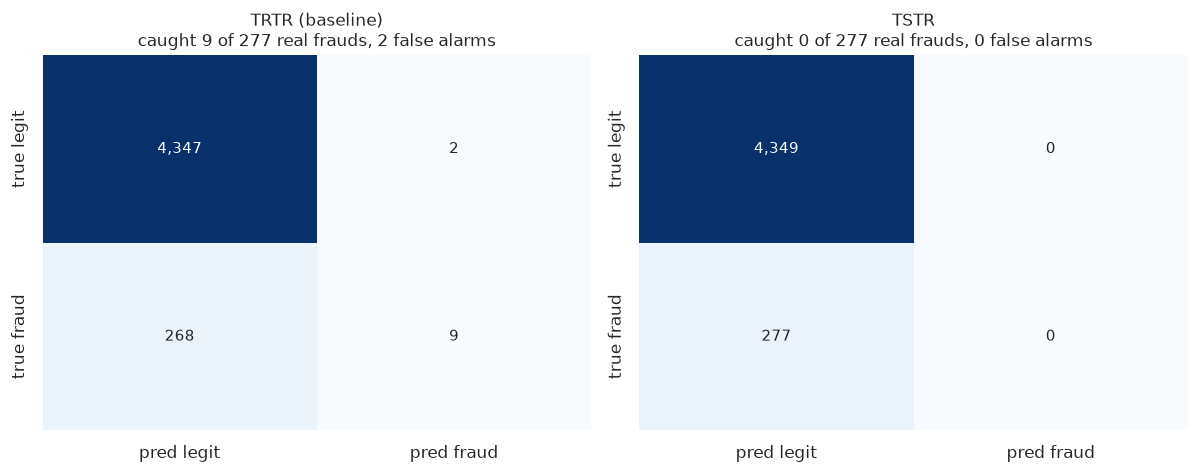

TRTR: true neg, false pos, false neg, true pos = [4347, 2, 268, 9]
TSTR: true neg, false pos, false neg, true pos = [4349, 0, 277, 0]


In [34]:
# Confusion matrices show what the two models actually did, claim by claim.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (nm, pr) in zip(axes, [("TRTR (baseline)", pred_trtr), ("TSTR", pred_tstr)]):
    cm = confusion_matrix(y_te_real, pr)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred legit", "pred fraud"],
                yticklabels=["true legit", "true fraud"])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{nm}\ncaught {tp} of {tp+fn} real frauds, {fp} false alarms", fontsize=11)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L4_confusion_matrices.png")
plt.show()

cm_trtr = confusion_matrix(y_te_real, pred_trtr)
cm_tstr = confusion_matrix(y_te_real, pred_tstr)
RESULTS["level4_cm_trtr"] = cm_trtr.tolist()
RESULTS["level4_cm_tstr"] = cm_tstr.tolist()
print("TRTR: true neg, false pos, false neg, true pos =", cm_trtr.ravel().tolist())
print("TSTR: true neg, false pos, false neg, true pos =", cm_tstr.ravel().tolist())

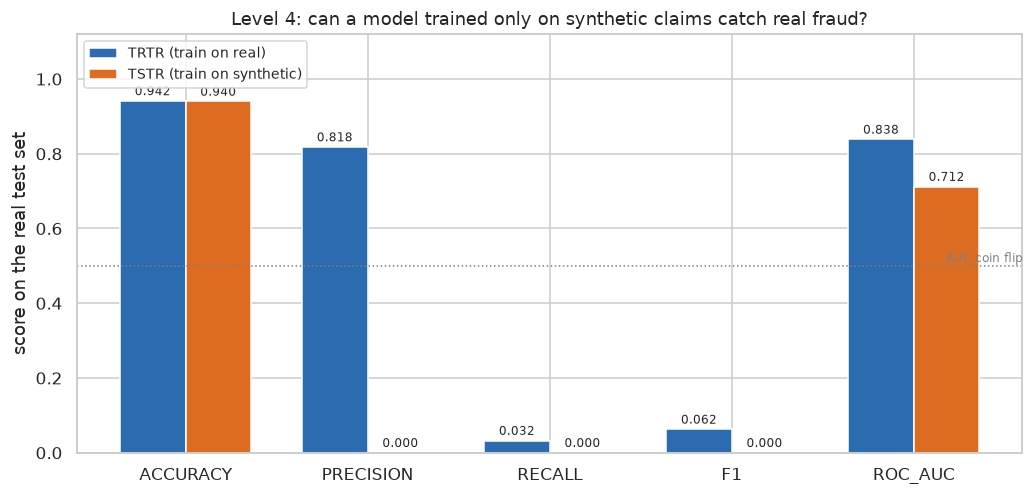

In [35]:
# Side by side bar chart of the five metrics
fig, ax = plt.subplots(figsize=(9.5, 4.6))
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
x = np.arange(len(metrics))
w = 0.36
b1 = ax.bar(x - w/2, [m_trtr[k] for k in metrics], w, label="TRTR (train on real)", color=C_REAL)
b2 = ax.bar(x + w/2, [m_tstr[k] for k in metrics], w, label="TSTR (train on synthetic)", color=C_SYNTH)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.text(len(metrics)-0.4, 0.51, "AUC coin flip", fontsize=8, color="grey", ha="right")
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylim(0, 1.12)
ax.set_ylabel("score on the real test set")
ax.set_title("Level 4: can a model trained only on synthetic claims catch real fraud?")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L4_tstr_vs_trtr.png")
plt.show()

In [36]:
# Level 4 verdict. We judge on the imbalance-aware metrics, with AUC as the primary signal
# because it measures how well the model ranks risk regardless of where the decision threshold sits.
auc_ratio = m_tstr["roc_auc"] / m_trtr["roc_auc"]
f1_ratio = m_tstr["f1"] / m_trtr["f1"] if m_trtr["f1"] > 0 else np.nan
recall_ratio = m_tstr["recall"] / m_trtr["recall"] if m_trtr["recall"] > 0 else np.nan

# How much better than random guessing is the TSTR model? AUC of 0.5 is the floor,
# so this measures the share of the achievable lift that survived.
lift_retained = (m_tstr["roc_auc"] - 0.5) / (m_trtr["roc_auc"] - 0.5)

print("LEVEL 4 RESULT")
print("=" * 78)
print("At the default 0.5 threshold (as reported in the main comparison table):")
print(f"  ROC-AUC  TRTR {m_trtr['roc_auc']:.4f}  ->  TSTR {m_tstr['roc_auc']:.4f}   ({auc_ratio*100:.1f}% of baseline)")
print(f"  F1       TRTR {m_trtr['f1']:.4f}  ->  TSTR {m_tstr['f1']:.4f}")
print(f"  Recall   TRTR {m_trtr['recall']:.4f}  ->  TSTR {m_tstr['recall']:.4f}")
print()
print(f"At the {ALERT_RATE:.0%} investigation budget (the practically meaningful operating point):")
print(f"  Recall   TRTR {topk_trtr['recall']:.4f}  ->  TSTR {topk_tstr['recall']:.4f}   ({tk_ratio*100:.1f}% of baseline)")
print(f"  Frauds caught  TRTR {topk_trtr['frauds_caught']}  ->  TSTR {topk_tstr['frauds_caught']} "
      f"(random ranking would catch about {random_recall*y_te_real.sum():.0f})")
print()
print(f"Share of the baseline's above-random ranking power retained by TSTR: {lift_retained:.1%}")
print()

# The verdict rests on AUC and on top-K recall. We deliberately do not lean on the default
# threshold F1: at a 6% base rate both models sit far below 0.5 probability almost everywhere,
# so that F1 is tiny and unstable for reasons that have nothing to do with synthetic data quality.
# THE FRAMEWORK'S CRITERION: the absolute gap between the two AUC scores on the shared real
# test set. Bands: under 0.02 fully equivalent, 0.02 to 0.05 acceptable with monitoring,
# above 0.05 investigate before deployment.
auc_gap = abs(m_tstr["roc_auc"] - m_trtr["roc_auc"])
level4_pass = (auc_gap < 0.05)
if auc_gap < 0.02:
    l4_band = "Fully equivalent"
elif auc_gap <= 0.05:
    l4_band = "Acceptable with monitoring"
else:
    l4_band = "Investigate before deployment"

l4 = "PASS" if level4_pass else f"FAIL ({l4_band})"

print(f"\nLEVEL 4, FRAMEWORK CRITERION (|TSTR AUC - TRTR AUC| < 0.05)")
print("-" * 60)
print(f"  TRTR AUC {m_trtr['roc_auc']:.4f} | TSTR AUC {m_tstr['roc_auc']:.4f}")
print(f"  Absolute gap = {auc_gap:.4f}  ->  {l4_band}")
print(f"VERDICT: {l4}")
print()
print("Supporting diagnostics (not the gate): the gap above is an absolute difference, which")
print("says nothing about how much USABLE signal survived. A model scoring 0.5 AUC is worthless")
print("regardless of the gap, so we also report how much lift above chance was retained and how")
print("the two models compare at a realistic investigation budget.")
print(f"  lift above chance retained : {lift_retained:.1%}")
print(f"  top-K recall ratio         : {tk_ratio:.1%}")

RESULTS["level4_auc_ratio"] = float(auc_ratio)
RESULTS["level4_f1_ratio"] = float(f1_ratio)
RESULTS["level4_recall_ratio"] = float(recall_ratio)
RESULTS["level4_lift_retained"] = float(lift_retained)
RESULTS["level4_auc_gap"] = float(auc_gap)
RESULTS["level4_band"] = l4_band
RESULTS["level4_pass"] = bool(level4_pass)
RESULTS["level4_verdict"] = l4

LEVEL 4 RESULT
At the default 0.5 threshold (as reported in the main comparison table):
  ROC-AUC  TRTR 0.8384  ->  TSTR 0.7123   (85.0% of baseline)
  F1       TRTR 0.0625  ->  TSTR 0.0000
  Recall   TRTR 0.0325  ->  TSTR 0.0000

At the 6% investigation budget (the practically meaningful operating point):
  Recall   TRTR 0.2599  ->  TSTR 0.1155   (44.4% of baseline)
  Frauds caught  TRTR 72  ->  TSTR 32 (random ranking would catch about 17)

Share of the baseline's above-random ranking power retained by TSTR: 62.7%


LEVEL 4, FRAMEWORK CRITERION (|TSTR AUC - TRTR AUC| < 0.05)
------------------------------------------------------------
  TRTR AUC 0.8384 | TSTR AUC 0.7123
  Absolute gap = 0.1261  ->  Investigate before deployment
VERDICT: FAIL (Investigate before deployment)

Supporting diagnostics (not the gate): the gap above is an absolute difference, which
says nothing about how much USABLE signal survived. A model scoring 0.5 AUC is worthless
regardless of the gap, so we also repo

**An important note:** CTGAN was trained on the **full** real dataset.  That means the claims in
our real test set were also part of CTGAN's training data. The synthetic rows therefore carry an
indirect trace of the test set, which can flatter the TSTR score compared with a stricter design
where the generator only ever sees the training split. As such TSTR number reported should be
read as an **upper bound** on how the synthetic data would perform against genuinely unseen claims.
This is noted again in the report's Findings section.

---
# Level 5. Privacy (Distance to Nearest Neighbour Ratio)

The whole reason to release synthetic data instead of real data is that it should not expose real
people. Level 5 tests that.

**The idea.** For each synthetic claim we find the closest real claim (distance `d1`) and the
second closest (distance `d2`), then compute the ratio:

$$\text{NNDR} = \frac{d_1}{d_2}$$

- A ratio **close to 0** means the synthetic record is sitting almost on top of one specific real
  claim and far from everything else. That is the fingerprint of **memorisation**: the generator
  has copied a real claimant rather than learned a pattern, and an attacker could use that record
  to make inferences about a real person.
- A ratio **close to 1** means the synthetic record is equally near to several real claims, so it
  cannot be traced back to any single individual. This is what we want.

We report the **5th percentile** of the ratio, because privacy risk lives in the worst cases, not
the average. We also report **DCR** (Distance to Closest Record, the raw `d1`), and, critically, we
compute the same statistics for **real records against other real records**. Without that baseline
a number like 0.7 is meaningless: we need to know what a genuinely safe dataset scores on the same
scale.

In [37]:
# Encode both datasets identically for distance computation:
#   categorical -> one-hot (so no false ordering is implied between categories)
#   numeric     -> min-max scaled to 0..1 (so Age does not dominate DriverRating by scale alone)
# Both encoders are fitted on the REAL data and applied unchanged to the synthetic data.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(real[CATEGORICAL_COLS].astype(str))

scaler = MinMaxScaler()
scaler.fit(real[NUMERIC_COLS])

def encode_for_distance(df):
    cat = ohe.transform(df[CATEGORICAL_COLS].astype(str))
    num = scaler.transform(df[NUMERIC_COLS])
    return np.hstack([num, cat])

R = encode_for_distance(real)
S = encode_for_distance(synth)

print("Encoded matrices for the distance computation")
print(f"  real      : {R.shape}")
print(f"  synthetic : {S.shape}")
print(f"  dimensions: {len(NUMERIC_COLS)} scaled numeric + {R.shape[1] - len(NUMERIC_COLS)} one-hot categorical")

Encoded matrices for the distance computation
  real      : (15420, 149)
  synthetic : (15420, 149)
  dimensions: 7 scaled numeric + 142 one-hot categorical


In [38]:
# Synthetic against real: for each synthetic claim find its two nearest real claims.
nn_real = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1).fit(R)
dist_s, _ = nn_real.kneighbors(S)

dcr_synth = dist_s[:, 0]                      # distance to closest real record
d2_synth = dist_s[:, 1]                       # distance to second closest
# Guard against division by zero: if d2 is 0 the record is an exact duplicate of two real rows.
nndr_synth = np.where(d2_synth > 0, dcr_synth / np.maximum(d2_synth, 1e-12), 0.0)

print("SYNTHETIC vs REAL")
print("=" * 46)
print(f"DCR  (distance to closest real record)  mean {dcr_synth.mean():.4f} | "
      f"5th pct {np.percentile(dcr_synth, 5):.4f} | min {dcr_synth.min():.4f}")
print(f"NNDR (d1/d2)                            mean {nndr_synth.mean():.4f} | "
      f"5th pct {np.percentile(nndr_synth, 5):.4f} | min {nndr_synth.min():.4f}")

SYNTHETIC vs REAL
DCR  (distance to closest real record)  mean 3.0579 | 5th pct 2.4903 | min 1.3569
NNDR (d1/d2)                            mean 0.9571 | 5th pct 0.8698 | min 0.4629


In [39]:
# The baseline. We split the real data in half and measure real records against OTHER real
# records the same way. This tells us what NNDR looks like for data that is definitionally
# safe to hold, since these are all genuine independent claims. Without it we cannot say
# whether the synthetic numbers above are good or bad.
half_a, half_b = train_test_split(real, test_size=0.5, random_state=SEED, stratify=real[TARGET])
A = encode_for_distance(half_a)
B = encode_for_distance(half_b)

nn_b = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1).fit(B)
dist_a, _ = nn_b.kneighbors(A)
dcr_base = dist_a[:, 0]
nndr_base = np.where(dist_a[:, 1] > 0, dcr_base / np.maximum(dist_a[:, 1], 1e-12), 0.0)

print("REAL vs REAL baseline (one half of the real data against the other half)")
print("=" * 72)
print(f"DCR   mean {dcr_base.mean():.4f} | 5th pct {np.percentile(dcr_base, 5):.4f} | min {dcr_base.min():.4f}")
print(f"NNDR  mean {nndr_base.mean():.4f} | 5th pct {np.percentile(nndr_base, 5):.4f} | min {nndr_base.min():.4f}")
print()
print("Read this as the reference point. Synthetic NNDR at or above the real-vs-real baseline")
print("means synthetic records are no easier to link to an individual than one real claim is")
print("to another, which is the standard we want to meet.")

REAL vs REAL baseline (one half of the real data against the other half)
DCR   mean 2.7709 | 5th pct 2.1212 | min 0.5543
NNDR  mean 0.9382 | 5th pct 0.8114 | min 0.2657

Read this as the reference point. Synthetic NNDR at or above the real-vs-real baseline
means synthetic records are no easier to link to an individual than one real claim is
to another, which is the standard we want to meet.


### The framework's privacy metric: DNNR

The framework defines a different quantity from the NNDR above, and this is the one its 1.5
threshold applies to:

$$\\text{DNNR} = \\frac{\\text{median}(d_{SR})}{\\text{median}(d_{RR})}$$

where $d_{SR}$ is each synthetic record's distance to its nearest real record, and $d_{RR}$ is each
real record's distance to its nearest *other* real record. The two metrics answer different
questions. NNDR asks "is this synthetic row suspiciously close to one particular real person?" and
is bounded above by 1. DNNR asks "is the synthetic cloud as a whole further from real records than
real records are from each other?" and is unbounded. A dataset can score well on one and badly on
the other, so we compute both.

We also compute an **anchor**: take one half of the real data and treat it *as if* it were
synthetic, then score it against the other half by exactly the same procedure. Those are genuine,
independent, definitionally non-memorised claims, so whatever they score is the realistic ceiling
for this feature space. Without that anchor a DNNR number cannot be interpreted, only compared to
a threshold that may or may not be attainable.

In [40]:
# d_RR: every real record against its nearest OTHER real record (leave-one-out, so we ask for
# two neighbours and discard the first, which is the record itself).
nn_rr = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1).fit(R)
dist_rr, _ = nn_rr.kneighbors(R)
d_rr = dist_rr[:, 1]

med_sr = float(np.median(dcr_synth))
med_rr = float(np.median(d_rr))
dnnr = med_sr / med_rr

# The anchor: half of the real data scored as if it were synthetic, against the other half,
# with that half's own leave-one-out distances as the denominator. Same construction, data
# that is known to be safe.
nn_bb = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1).fit(B)
d_ab = nn_bb.kneighbors(A)[0][:, 0]          # half A against half B, nearest
d_bb = nn_bb.kneighbors(B)[0][:, 1]          # half B against itself, leave one out
dnnr_anchor = float(np.median(d_ab) / np.median(d_bb))

if dnnr > 1.5:
    dnnr_band = "Privacy preserved"
elif dnnr > 1.0:
    dnnr_band = "Borderline"
else:
    dnnr_band = "Memorisation risk"

level5_framework_pass = (dnnr > 1.5)

print("LEVEL 5, FRAMEWORK CRITERION (DNNR > 1.5)")
print("=" * 66)
print(f"  median d_SR (synthetic to nearest real) : {med_sr:.4f}")
print(f"  median d_RR (real to nearest other real): {med_rr:.4f}")
print(f"  DNNR = {med_sr:.4f} / {med_rr:.4f}       : {dnnr:.4f}")
print(f"  Band                                    : {dnnr_band}")
print(f"VERDICT: {'PASS' if level5_framework_pass else 'FAIL'} against the 1.5 threshold")
print()
print(f"  ANCHOR: real data scored against real data by the same method = {dnnr_anchor:.4f}")
print(f"  The synthetic data scores {dnnr:.4f}, which is "
      f"{'above' if dnnr > dnnr_anchor else 'below'} that anchor.")
print()
print("Interpretation. Genuinely independent real claims - data that cannot be memorised because")
print(f"it was never generated - score {dnnr_anchor:.4f} on this metric. The 1.5 threshold is therefore")
print("not reachable in this feature space by any generator, real data included. The distances")
print("are dominated by one-hot categorical dimensions, where every pair sits at roughly the")
print("square root of the number of mismatched categories, compressing any ratio of medians")
print("toward 1. We report the failure against the stated threshold and the anchor together.")

RESULTS["level5_dnnr"] = float(dnnr)
RESULTS["level5_dnnr_median_d_sr"] = med_sr
RESULTS["level5_dnnr_median_d_rr"] = med_rr
RESULTS["level5_dnnr_anchor"] = dnnr_anchor
RESULTS["level5_dnnr_band"] = dnnr_band
RESULTS["level5_framework_pass"] = bool(level5_framework_pass)

LEVEL 5, FRAMEWORK CRITERION (DNNR > 1.5)
  median d_SR (synthetic to nearest real) : 3.0343
  median d_RR (real to nearest other real): 2.6207
  DNNR = 3.0343 / 2.6207       : 1.1578
  Band                                    : Borderline
VERDICT: FAIL against the 1.5 threshold

  ANCHOR: real data scored against real data by the same method = 1.0100
  The synthetic data scores 1.1578, which is above that anchor.

Interpretation. Genuinely independent real claims - data that cannot be memorised because
it was never generated - score 1.0100 on this metric. The 1.5 threshold is therefore
not reachable in this feature space by any generator, real data included. The distances
are dominated by one-hot categorical dimensions, where every pair sits at roughly the
square root of the number of mismatched categories, compressing any ratio of medians
toward 1. We report the failure against the stated threshold and the anchor together.


In [41]:
# The most direct memorisation test there is: We compare the full 32-column records as strings.
real_keys = set(map(tuple, real.astype(str).values))
synth_keys = list(map(tuple, synth.astype(str).values))
exact_matches = sum(1 for k in synth_keys if k in real_keys)

# Distance zero is the same test done in the encoded space, as a cross-check
zero_distance = int((dcr_synth < 1e-9).sum())

print("MEMORISATION CHECKS")
print("=" * 52)
print(f"Synthetic rows that are exact copies of a real row : {exact_matches} "
      f"({exact_matches/len(synth):.4%})")
print(f"Synthetic rows at distance 0 from a real record    : {zero_distance} "
      f"({zero_distance/len(synth):.4%})")
print(f"Synthetic rows with NNDR below 0.10 (near copies)  : {int((nndr_synth < 0.10).sum())} "
      f"({(nndr_synth < 0.10).mean():.4%})")

RESULTS["level5_exact_matches"] = int(exact_matches)
RESULTS["level5_zero_distance"] = zero_distance
RESULTS["level5_nndr_below_0.1"] = int((nndr_synth < 0.10).sum())

MEMORISATION CHECKS
Synthetic rows that are exact copies of a real row : 0 (0.0000%)
Synthetic rows at distance 0 from a real record    : 0 (0.0000%)
Synthetic rows with NNDR below 0.10 (near copies)  : 0 (0.0000%)


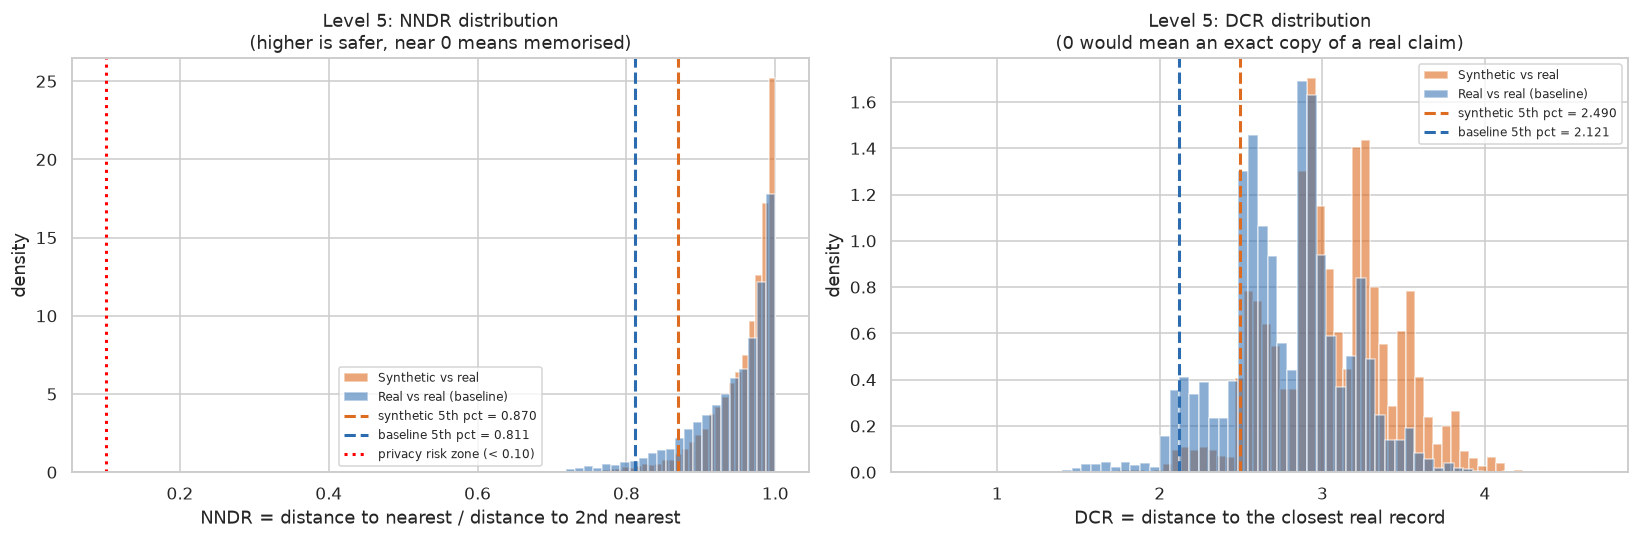

In [42]:
# Plot the distributions of NNDR and DCR, synthetic against the real-vs-real baseline.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(nndr_synth, bins=60, alpha=0.6, label="Synthetic vs real", color=C_SYNTH, density=True)
axes[0].hist(nndr_base, bins=60, alpha=0.55, label="Real vs real (baseline)", color=C_REAL, density=True)
p5 = np.percentile(nndr_synth, 5)
p5b = np.percentile(nndr_base, 5)
axes[0].axvline(p5, color=C_SYNTH, ls="--", lw=2, label=f"synthetic 5th pct = {p5:.3f}")
axes[0].axvline(p5b, color=C_REAL, ls="--", lw=2, label=f"baseline 5th pct = {p5b:.3f}")
axes[0].axvline(0.10, color="red", ls=":", lw=2, label="privacy risk zone (< 0.10)")
axes[0].set_xlabel("NNDR = distance to nearest / distance to 2nd nearest")
axes[0].set_ylabel("density")
axes[0].set_title("Level 5: NNDR distribution\n(higher is safer, near 0 means memorised)")
axes[0].legend(fontsize=8)

axes[1].hist(dcr_synth, bins=60, alpha=0.6, label="Synthetic vs real", color=C_SYNTH, density=True)
axes[1].hist(dcr_base, bins=60, alpha=0.55, label="Real vs real (baseline)", color=C_REAL, density=True)
axes[1].axvline(np.percentile(dcr_synth, 5), color=C_SYNTH, ls="--", lw=2,
                label=f"synthetic 5th pct = {np.percentile(dcr_synth,5):.3f}")
axes[1].axvline(np.percentile(dcr_base, 5), color=C_REAL, ls="--", lw=2,
                label=f"baseline 5th pct = {np.percentile(dcr_base,5):.3f}")
axes[1].set_xlabel("DCR = distance to the closest real record")
axes[1].set_ylabel("density")
axes[1].set_title("Level 5: DCR distribution\n(0 would mean an exact copy of a real claim)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/L5_privacy_dnnr.png")
plt.show()

In [43]:
# Level 5 verdict
p5_synth = float(np.percentile(nndr_synth, 5))
p5_base = float(np.percentile(nndr_base, 5))
dcr5_synth = float(np.percentile(dcr_synth, 5))
dcr5_base = float(np.percentile(dcr_base, 5))

privacy_table = pd.DataFrame({
    "metric": ["NNDR mean", "NNDR 5th percentile", "NNDR minimum",
               "DCR mean", "DCR 5th percentile", "DCR minimum"],
    "synthetic_vs_real": [round(float(nndr_synth.mean()), 4), round(p5_synth, 4),
                          round(float(nndr_synth.min()), 4),
                          round(float(dcr_synth.mean()), 4), round(dcr5_synth, 4),
                          round(float(dcr_synth.min()), 4)],
    "real_vs_real_baseline": [round(float(nndr_base.mean()), 4), round(p5_base, 4),
                              round(float(nndr_base.min()), 4),
                              round(float(dcr_base.mean()), 4), round(dcr5_base, 4),
                              round(float(dcr_base.min()), 4)],
})
print(privacy_table.to_string(index=False))
print()

checks5 = {
    "No exact copies of real claims": exact_matches == 0,
    "NNDR 5th percentile above the 0.10 risk threshold": p5_synth > 0.10,
    "NNDR 5th percentile at or above the real-vs-real baseline": p5_synth >= p5_base * 0.95,
    "Fewer than 0.1% of rows in the near-copy zone": (nndr_synth < 0.10).mean() < 0.001,
    "DNNR at or above the real-vs-real anchor": dnnr >= dnnr_anchor,
}

print("LEVEL 5 RESULT")
print("=" * 66)
for k, v in checks5.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

# Two distinct questions, kept separate on purpose.
#   level5_pass       - does it meet the framework's STATED criterion? (DNNR > 1.5)
#   level5_evidence   - is there positive evidence of memorisation, on any measure?
# The first is the criterion we adopted for this level. The second is what a release
# decision has to rest on, because the first is unreachable in this feature space.
level5_pass = bool(level5_framework_pass)
level5_evidence_pass = all(checks5.values())

print()
print(f"  Against the framework criterion (DNNR {dnnr:.4f} > 1.5): "
      f"{'PASS' if level5_pass else 'FAIL'}")
print(f"  Evidence of memorisation on any measure               : "
      f"{'NONE FOUND' if level5_evidence_pass else 'PRESENT'}")
print()
print(f"VERDICT: {'PASS' if level5_pass else 'FAIL against the stated threshold, no memorisation evidence'}")

RESULTS["level5_evidence_pass"] = bool(level5_evidence_pass)
RESULTS["level5_nndr_mean"] = float(nndr_synth.mean())
RESULTS["level5_nndr_p5"] = p5_synth
RESULTS["level5_nndr_min"] = float(nndr_synth.min())
RESULTS["level5_nndr_p5_baseline"] = p5_base
RESULTS["level5_dcr_mean"] = float(dcr_synth.mean())
RESULTS["level5_dcr_p5"] = dcr5_synth
RESULTS["level5_dcr_min"] = float(dcr_synth.min())
RESULTS["level5_dcr_p5_baseline"] = dcr5_base
RESULTS["level5_checks"] = {k: bool(v) for k, v in checks5.items()}
RESULTS["level5_pass"] = bool(level5_pass)
RESULTS["level5_privacy_table"] = privacy_table.to_dict("records")

             metric  synthetic_vs_real  real_vs_real_baseline
          NNDR mean             0.9571                 0.9382
NNDR 5th percentile             0.8698                 0.8114
       NNDR minimum             0.4629                 0.2657
           DCR mean             3.0579                 2.7709
 DCR 5th percentile             2.4903                 2.1212
        DCR minimum             1.3569                 0.5543

LEVEL 5 RESULT
  PASS  No exact copies of real claims
  PASS  NNDR 5th percentile above the 0.10 risk threshold
  PASS  NNDR 5th percentile at or above the real-vs-real baseline
  PASS  Fewer than 0.1% of rows in the near-copy zone
  PASS  DNNR at or above the real-vs-real anchor

  Against the framework criterion (DNNR 1.1578 > 1.5): FAIL
  Evidence of memorisation on any measure               : NONE FOUND

VERDICT: FAIL against the stated threshold, no memorisation evidence


---
# Overall scorecard and release decision

Every level has now returned a verdict. Here they are in one place, followed by the release
recommendation.

In [44]:
# Each row records WHICH criterion decided it, so the scorecard is self documenting.
scorecard = pd.DataFrame([
    {"level": "1. Summary Statistics", "criterion": "Framework",
     "test": "All means within 10% of real",
     "headline": f"largest mean difference {RESULTS['level1_max_mean_err']:.2f}%, "
                 f"{len(RESULTS['level1_flagged_10pct_of_mean'])} columns flagged",
     "verdict": "PASS" if RESULTS["level1_pass"] else "FAIL"},
    {"level": "2. Visual Distributions", "criterion": "Report",
     "test": "mean TVD < 0.10, correlation error < 0.10, fraud-correlation error < 0.05",
     "headline": f"TVD {RESULTS['level2_mean_tvd']:.3f}, correlation {RESULTS['level2_corr_mean_abs_err']:.3f}, "
                 f"fraud {RESULTS['level2_fraud_corr_mae']:.3f}",
     "verdict": "PASS" if RESULTS["level2_pass"] else "FAIL"},
    {"level": "3a+3b. Statistical Tests", "criterion": "Report",
     "test": "mean KS < 0.10, mean Cramer's V < 0.10, no large effects",
     "headline": f"mean KS {RESULTS['level3_mean_ks']:.3f}, mean V {RESULTS['level3_mean_cramers_v']:.3f}, "
                 f"{RESULTS['level3_n_large']} large",
     "verdict": "PASS" if RESULTS["level3ab_pass"] else "FAIL"},
    {"level": "3c. Wasserstein", "criterion": "Framework",
     "test": "Wasserstein / sigma(real) < 0.15 per feature",
     "headline": f"{RESULTS['level3c_n_poor']}/{len(NUMERIC_COLS)} columns above 0.15, "
                 f"max {RESULTS['level3c_max_w_sigma']:.3f}",
     "verdict": "PASS" if RESULTS["level3c_pass"] else "FAIL"},
    {"level": "4. ML Utility (TSTR)", "criterion": "Framework",
     "test": "|TSTR AUC - TRTR AUC| < 0.05",
     "headline": f"gap {RESULTS['level4_auc_gap']:.4f} ({RESULTS['level4_band']}), "
                 f"{RESULTS['level4_lift_retained']:.0%} of lift retained",
     "verdict": "PASS" if RESULTS["level4_pass"] else "FAIL"},
    {"level": "5. Privacy (DNNR)", "criterion": "Framework",
     "test": "DNNR > 1.5",
     "headline": f"DNNR {RESULTS['level5_dnnr']:.4f} vs real-data anchor "
                 f"{RESULTS['level5_dnnr_anchor']:.4f}, {RESULTS['level5_exact_matches']} exact copies",
     "verdict": "PASS" if RESULTS["level5_pass"] else "FAIL"},
])

print("VALIDATION SCORECARD")
print("=" * 140)
print(scorecard.to_string(index=False))
print("=" * 140)

n_levels = len(scorecard)
n_passed = int((scorecard["verdict"] == "PASS").sum())
print(f"\nLevels passed: {n_passed} of {n_levels}")

RESULTS["scorecard"] = scorecard.to_dict("records")
RESULTS["n_levels"] = n_levels
RESULTS["n_levels_passed"] = n_passed

VALIDATION SCORECARD
                   level criterion                                                                      test                                                         headline verdict
   1. Summary Statistics Framework                                              All means within 10% of real                largest mean difference 10.12%, 1 columns flagged    FAIL
 2. Visual Distributions    Report mean TVD < 0.10, correlation error < 0.10, fraud-correlation error < 0.05                        TVD 0.101, correlation 0.030, fraud 0.022    FAIL
3a+3b. Statistical Tests    Report                  mean KS < 0.10, mean Cramer's V < 0.10, no large effects                             mean KS 0.083, mean V 0.133, 2 large    FAIL
         3c. Wasserstein Framework                              Wasserstein / sigma(real) < 0.15 per feature                                4/7 columns above 0.15, max 0.244    FAIL
    4. ML Utility (TSTR) Framework                                   

In [45]:
# Saving results of everything
RESULTS["seed"] = SEED
RESULTS["torch_threads"] = TORCH_THREADS
RESULTS["generated_on"] = time.strftime("%Y-%m-%d %H:%M:%S")

metrics_path = os.path.join(OUT_DIR, "validation_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)

print(f"Saved {len(RESULTS)} result keys to {metrics_path}")
print()
print("Saved:")
for p in [real_out, synth_out, metrics_path]:
    print(f"  {p}  ({os.path.getsize(p)/1024:.0f} KB)")
print(f"  {FIG_DIR}/ : {len(os.listdir(FIG_DIR))} figures")
for f_ in sorted(os.listdir(FIG_DIR)):
    print(f"      {f_}")

Saved 112 result keys to outputs/validation_metrics.json

Saved:
  outputs/real_carclaims_processed.csv  (3496 KB)
  outputs/synthetic_carclaims_ctgan.csv  (3521 KB)
  outputs/validation_metrics.json  (38 KB)
  figures/ : 8 figures
      00_class_balance.png
      L2_bars_categorical.png
      L2_correlation_heatmaps.png
      L2_kde_numeric.png
      L3_effect_sizes.png
      L4_confusion_matrices.png
      L4_tstr_vs_trtr.png
      L5_privacy_dnnr.png
